In [1]:
import json
import pickle
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

ff_dir = Path('results/benchmark/ff_benchmark')
tree_dir = Path('results/benchmark/tree_benchmark')
mlp_dir = Path('results/benchmark/mlp_benchmark')
dppt_dir = Path('results/transformer')
dppt_hpt_dir = Path('results/transformer-hpt')

## Fama MacBeth

In [2]:
factor_order = ['value', 'momentum', 'profitability', 'investment', 'size']

factor_results = {}
for fname in factor_order:
    factor_results[fname] = {
        'returns_ls_unscaled': np.load(ff_dir / f'{fname}_long_short_unscaled.npy'),
        'returns_ls_scaled': np.load(ff_dir / f'{fname}_long_short_scaled.npy'),
        'returns_lo_unscaled': np.load(ff_dir / f'{fname}_long_only_unscaled.npy'),
        'returns_lo_scaled': np.load(ff_dir / f'{fname}_long_only_scaled.npy'),
    }

market_rets = np.load(ff_dir / 'market_value_weighted_long_only_unscaled.npy')
market_scaled = np.load(ff_dir / 'market_value_weighted_long_only_scaled.npy')

fm_ls_rets = np.load(ff_dir / 'fm_regression_long_short_unscaled.npy')
fm_ls_scaled = np.load(ff_dir / 'fm_regression_long_short_scaled.npy')
fm_lo_rets = np.load(ff_dir / 'fm_regression_long_only_unscaled.npy')
fm_lo_scaled = np.load(ff_dir / 'fm_regression_long_only_scaled.npy')

ff_monthly = pd.read_csv(ff_dir / 'ff_per_month_metrics.csv')
ff_monthly['eom'] = pd.to_datetime(ff_monthly['eom'])

ff_per_year = pd.read_csv(ff_dir / 'ff_per_year_metrics.csv')
fm_betas = pd.read_csv(ff_dir / 'fm_monthly_betas.csv', index_col=0, parse_dates=True)
ff_summary = pd.read_csv(ff_dir / 'fama_french_summary.csv')

results_dir = Path('plots') / ff_dir.name
results_dir.mkdir(parents=True, exist_ok=True)
print(f'factor portfolios loaded: {len(factor_results)}')
print(f'market returns: {len(market_rets)} months')
print(f'fm returns: {len(fm_ls_rets)} months')
print()
print('fama-french headline summary')
print(ff_summary.to_string(index=False))

factor portfolios loaded: 5
market returns: 60 months
fm returns: 60 months

fama-french headline summary
             strategy  portfolio  scaling  sharpe     se  ann_ret  ann_vol  cum_return  max_dd  n_obs
market_value_weighted  long_only unscaled  0.3160 0.1323     3.67    11.61       16.12   21.43     60
market_value_weighted  long_only   scaled  0.2816 0.1316     3.16    11.24       13.46   24.28     60
                value long_short unscaled  1.0352 0.1600    10.23     9.88       62.48    7.53     60
                value long_short   scaled  0.9697 0.1565     9.25     9.53       54.99   10.69     60
                value  long_only unscaled  0.7477 0.1460    10.36    13.86       59.88   20.05     60
                value  long_only   scaled  0.6663 0.1427     7.27    10.92       39.59   18.50     60
             momentum long_short unscaled -0.0311 0.1291    -0.52    16.68       -9.31   28.47     60
             momentum long_short   scaled  0.1099 0.1295     1.51    13.72    

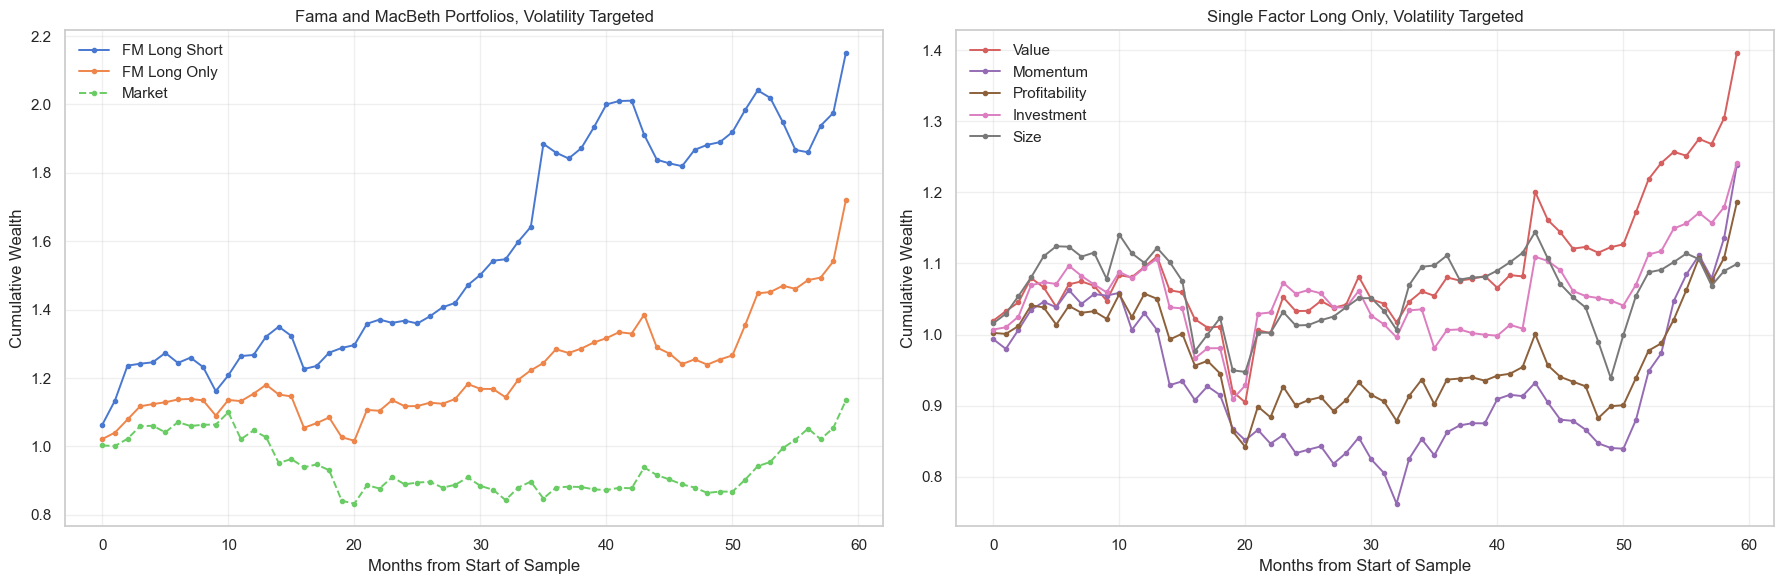

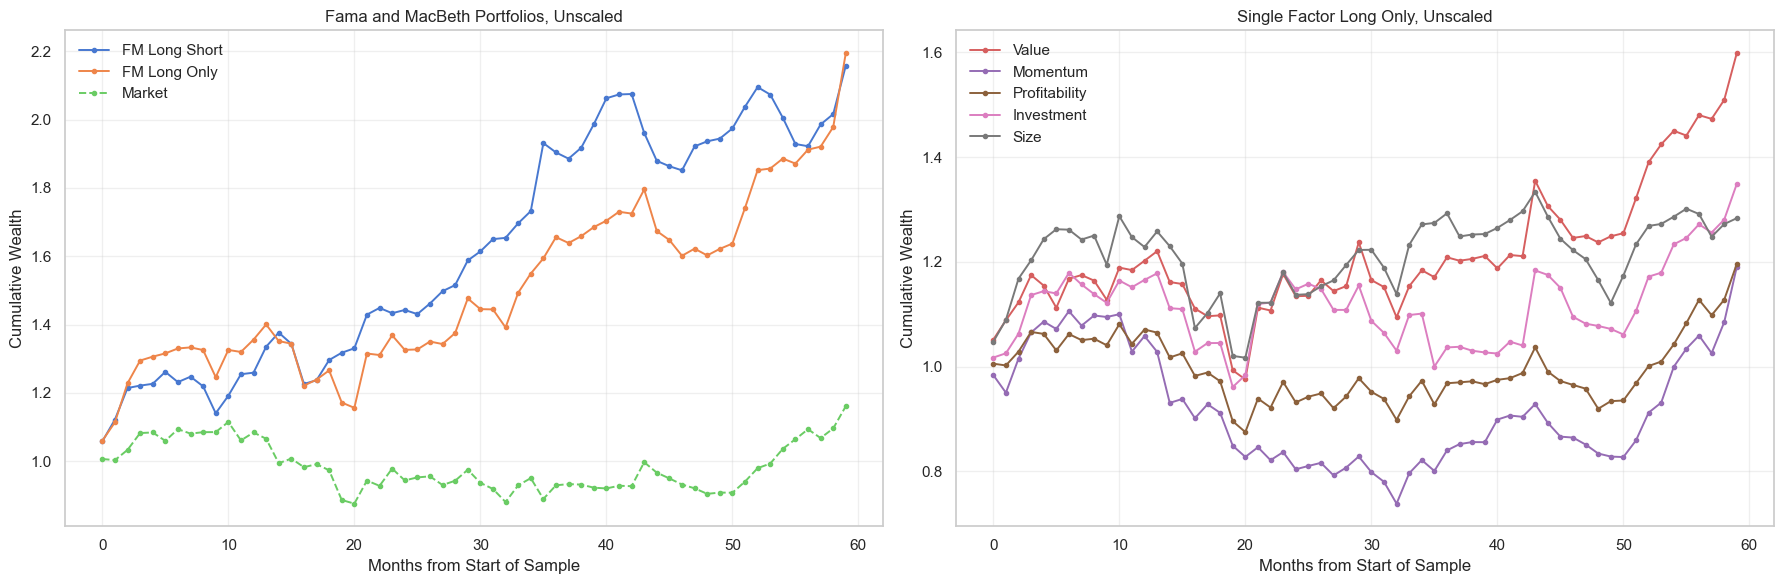

In [3]:
sns.set_theme(style="whitegrid")
palette = sns.color_palette("muted", 8)

fm_ls_color = palette[0]
fm_lo_color = palette[1]
market_color = palette[2]
factor_colors = palette[3:]

marker_style = {'marker': 'o', 'markersize': 3}


fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ax = axes[0]
ax.plot(np.cumprod(1 + fm_ls_scaled), label='FM Long Short', color=fm_ls_color, linewidth=1.4, **marker_style)
ax.plot(np.cumprod(1 + fm_lo_scaled), label='FM Long Only', color=fm_lo_color, linewidth=1.4, **marker_style)
ax.plot(np.cumprod(1 + market_scaled), label='Market', color=market_color, linestyle='--', linewidth=1.4, **marker_style)

ax.set_xlabel('Months from Start of Sample')
ax.set_ylabel('Cumulative Wealth')
ax.set_title('Fama and MacBeth Portfolios, Volatility Targeted')
ax.legend(frameon=False)
ax.grid(alpha=0.3)

ax = axes[1]
for k, factor in enumerate(factor_order):
    if factor in factor_results:
        ax.plot(np.cumprod(1 + factor_results[factor]['returns_lo_scaled']), label=factor.title(), color=factor_colors[k % len(factor_colors)], linewidth=1.4, **marker_style)

ax.set_xlabel('Months from Start of Sample')
ax.set_ylabel('Cumulative Wealth')
ax.set_title('Single Factor Long Only, Volatility Targeted')
ax.legend(frameon=False)
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(results_dir / 'ff_cumulative_scaled.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)


fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ax = axes[0]
ax.plot(np.cumprod(1 + fm_ls_rets), label='FM Long Short', color=fm_ls_color, linewidth=1.4, **marker_style)
ax.plot(np.cumprod(1 + fm_lo_rets), label='FM Long Only', color=fm_lo_color, linewidth=1.4, **marker_style)
ax.plot(np.cumprod(1 + np.asarray(market_rets)), label='Market', color=market_color, linestyle='--', linewidth=1.4, **marker_style)

ax.set_xlabel('Months from Start of Sample')
ax.set_ylabel('Cumulative Wealth')
ax.set_title('Fama and MacBeth Portfolios, Unscaled')
ax.legend(frameon=False)
ax.grid(alpha=0.3)

ax = axes[1]
for k, factor in enumerate(factor_order):
    if factor in factor_results:
        ax.plot(np.cumprod(1 + factor_results[factor]['returns_lo_unscaled']), label=factor.title(), color=factor_colors[k % len(factor_colors)], linewidth=1.4, **marker_style)

ax.set_xlabel('Months from Start of Sample')
ax.set_ylabel('Cumulative Wealth')
ax.set_title('Single Factor Long Only, Unscaled')
ax.legend(frameon=False)
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(results_dir / 'ff_cumulative_unscaled.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

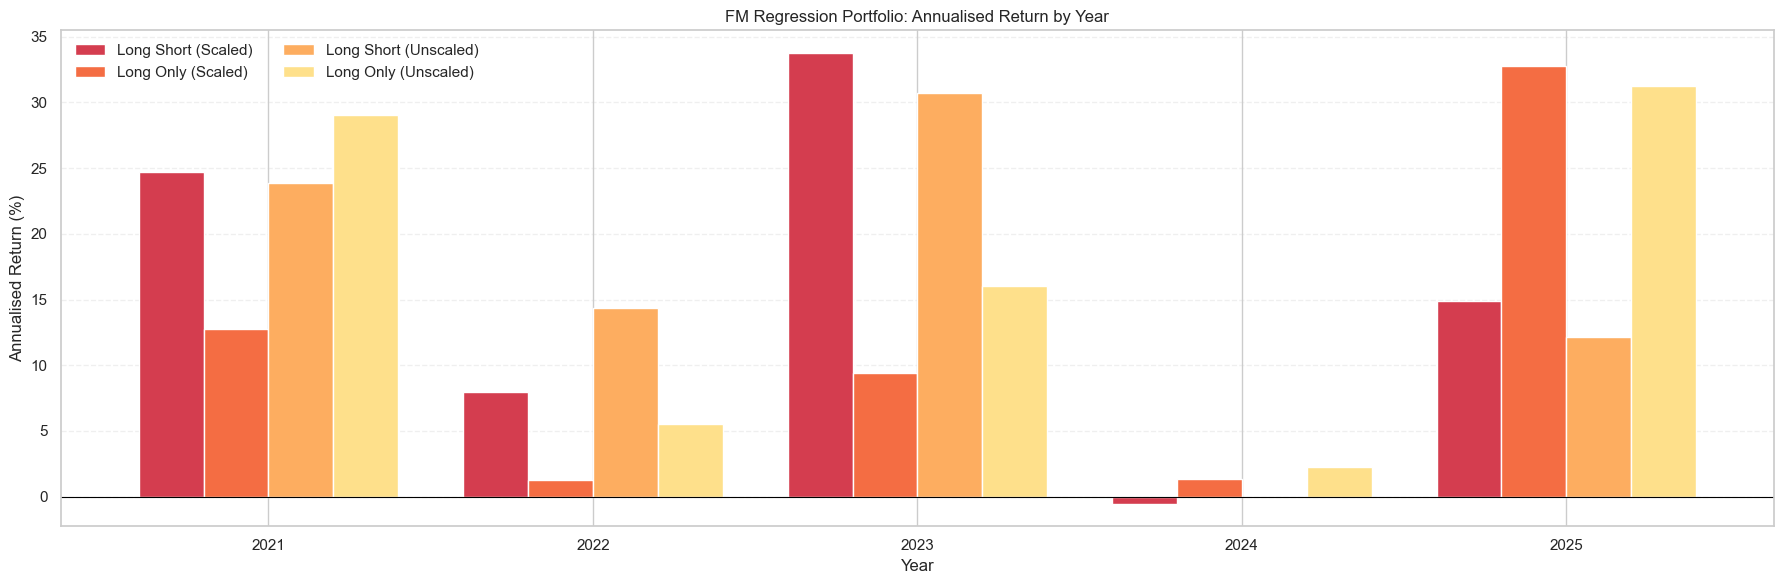

In [4]:
cmap = sns.color_palette("Spectral", as_cmap=True)
palette = [cmap(x) for x in np.linspace(0.1, 0.4, 4)]
sns.set_theme(style="whitegrid")


# Separate scaled and unscaled results
fm_scaled = ff_per_year[
    (ff_per_year['strategy'] == 'fm_regression') &
    (ff_per_year['scaling'] == 'scaled')
].copy()

fm_unscaled = ff_per_year[
    (ff_per_year['strategy'] == 'fm_regression') &
    (ff_per_year['scaling'] == 'unscaled')
].copy()

years_ff = sorted(ff_per_year['year'].unique())
x_ff = np.arange(len(years_ff))
width_ff = 0.2

def _ff_val(df, portfolio, year, col):
    sub = df[(df['portfolio'] == portfolio) & (df['year'] == year)]
    return float(sub[col].to_numpy()[0]) if len(sub) > 0 else 0.0

# Scaled
ls_scaled = [_ff_val(fm_scaled, 'long_short', y, 'ann_ret') for y in years_ff]
lo_scaled = [_ff_val(fm_scaled, 'long_only', y, 'ann_ret') for y in years_ff]
# Unscaled
ls_unscaled = [_ff_val(fm_unscaled, 'long_short', y, 'ann_ret') for y in years_ff]
lo_unscaled = [_ff_val(fm_unscaled, 'long_only', y, 'ann_ret') for y in years_ff]

fig, ax = plt.subplots(figsize=(18, 6))

# Plot bars with four different colours
ax.bar(x_ff - 1.5 * width_ff,ls_scaled,width_ff,label='Long Short (Scaled)',color=palette[0])
ax.bar(x_ff - 0.5 * width_ff,lo_scaled,width_ff,label='Long Only (Scaled)',color=palette[1])
ax.bar(x_ff + 0.5 * width_ff,ls_unscaled,width_ff,label='Long Short (Unscaled)',color=palette[2])
ax.bar(x_ff + 1.5 * width_ff,lo_unscaled,width_ff,label='Long Only (Unscaled)',color=palette[3])

# Formatting
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x_ff)
ax.set_xticklabels(years_ff)
ax.set_xlabel('Year')
ax.set_ylabel('Annualised Return (%)')
ax.set_title('FM Regression Portfolio: Annualised Return by Year')
ax.legend(frameon=False, ncol=2)
ax.grid(axis='y', linestyle='--', alpha=0.3)

fig.tight_layout()
fig.savefig(results_dir / 'ff_per_year_bar_scaled_unscaled.png', dpi=300)
plt.show()
plt.close(fig)

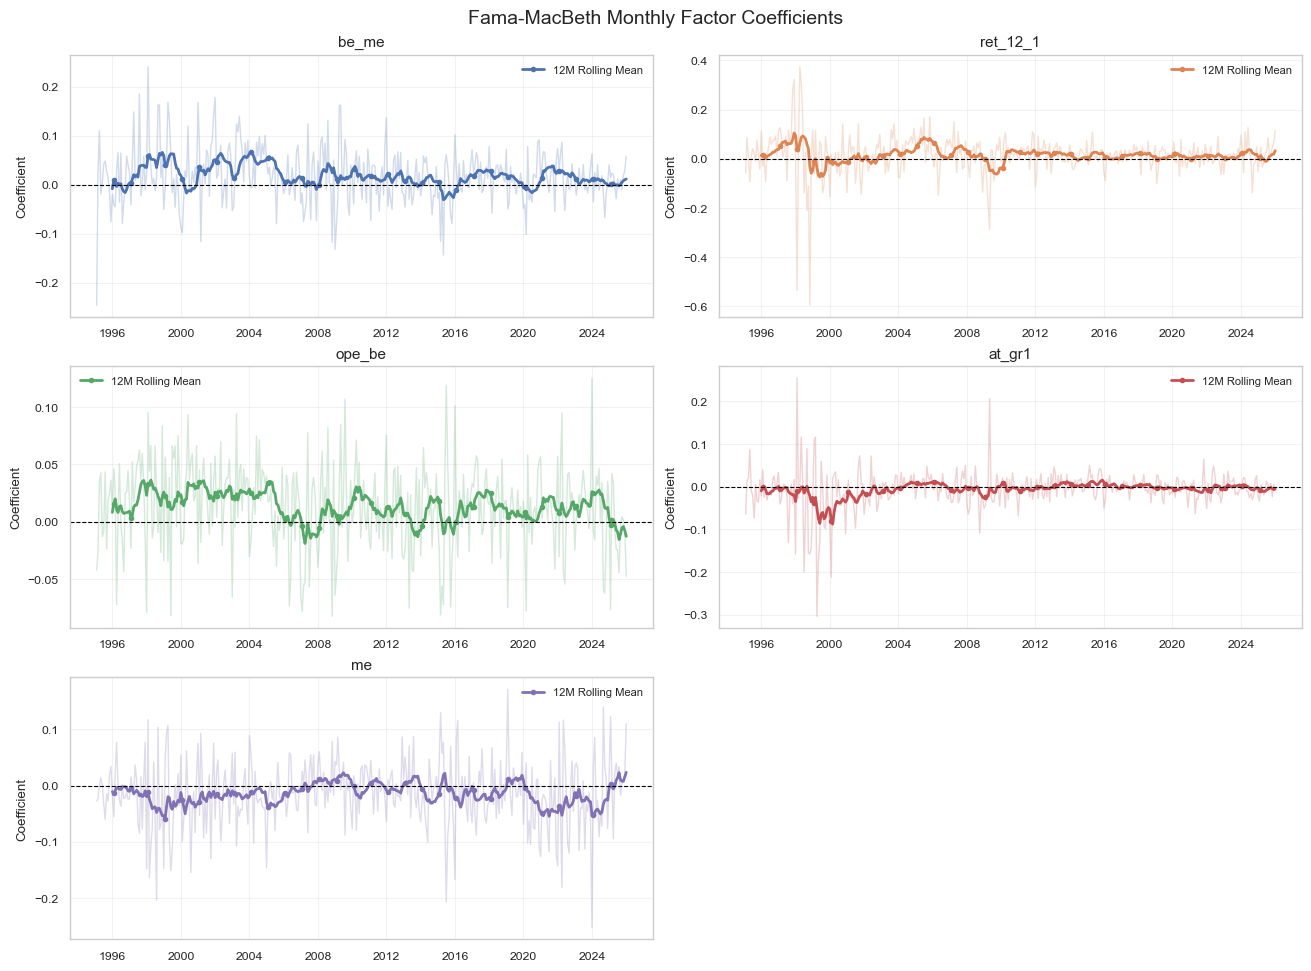

In [5]:
sns.set_theme(style="whitegrid", context="paper")
palette = sns.color_palette("deep")

cols_to_plot = [c for c in fm_betas.columns if c != 'intercept']
n_c = len(cols_to_plot)
n_rows_b = int(np.ceil(n_c / 2))

fig, axes = plt.subplots(n_rows_b, 2, figsize=(13, n_rows_b * 3.2), constrained_layout=True)
axes = np.array(axes).flatten()

for k, col in enumerate(cols_to_plot):
    ax = axes[k]

    raw = fm_betas[col].dropna()
    roll = raw.rolling(12).mean()
    colour = palette[k % len(palette)]
    ax.plot(raw.index, raw, color=colour, alpha=0.25, linewidth=1)
    ax.plot(roll.index, roll, color=colour, linewidth=2, marker='o', markersize=3, markevery=12, label='12M Rolling Mean')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('Coefficient')
    ax.legend(frameon=False, fontsize=8, loc='best')
    ax.grid(alpha=0.25)

for k in range(n_c, len(axes)):
    axes[k].set_visible(False)

fig.suptitle('Fama-MacBeth Monthly Factor Coefficients', fontsize=14)

fig.savefig(results_dir / 'ff_fm_beta_stability.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

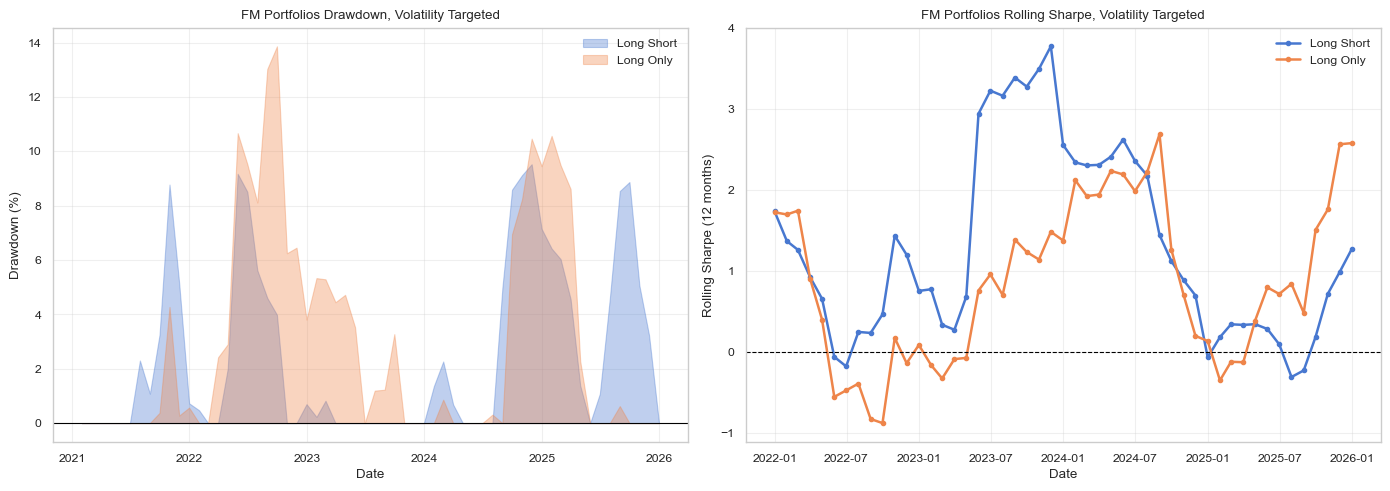

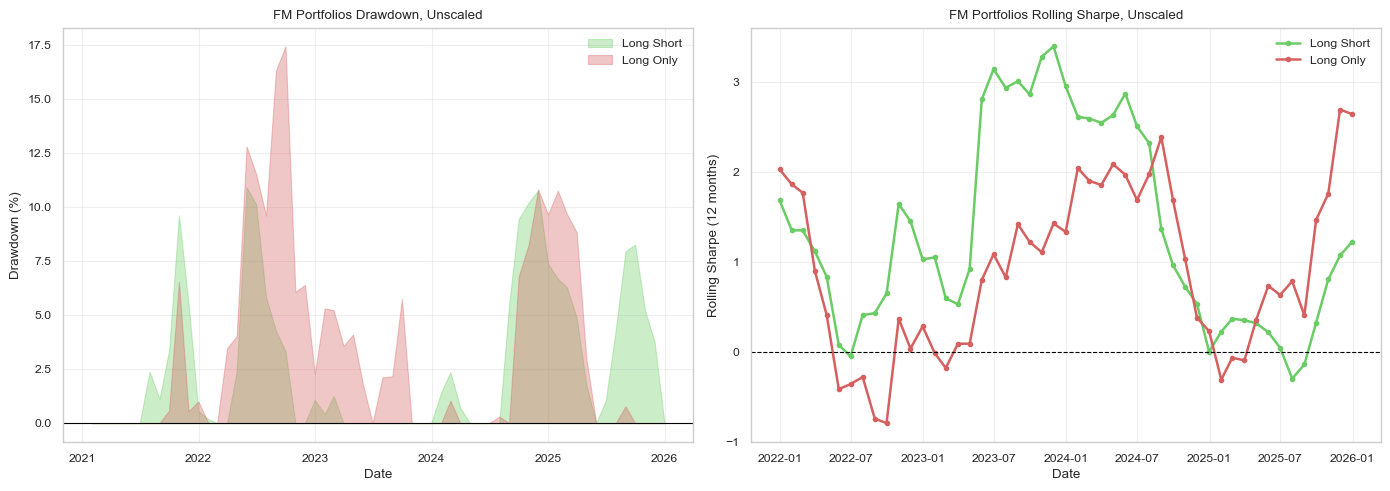

In [6]:
sns.set_theme(style="whitegrid", context="paper")

palette = sns.color_palette("muted", 6)

fm_ls_mo = ff_monthly[(ff_monthly['strategy'] == 'fm_regression') & (ff_monthly['portfolio'] == 'long_short') & (ff_monthly['scaling'] == 'scaled')].sort_values('eom')
fm_lo_mo = ff_monthly[(ff_monthly['strategy'] == 'fm_regression') & (ff_monthly['portfolio'] == 'long_only') & (ff_monthly['scaling'] == 'scaled')].sort_values('eom')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.fill_between(fm_ls_mo['eom'], fm_ls_mo['drawdown'] * 100, color=palette[0], alpha=0.35, label='Long Short')
ax.fill_between(fm_lo_mo['eom'], fm_lo_mo['drawdown'] * 100, color=palette[1], alpha=0.35, label='Long Only')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Date')
ax.set_ylabel('Drawdown (%)')
ax.set_title('FM Portfolios Drawdown, Volatility Targeted')
ax.legend(frameon=False)
ax.grid(alpha=0.3)

ax = axes[1]
valid_ls = fm_ls_mo['rolling_sharpe_12m'].notna()
valid_lo = fm_lo_mo['rolling_sharpe_12m'].notna()
ax.plot(fm_ls_mo.loc[valid_ls, 'eom'], fm_ls_mo.loc[valid_ls, 'rolling_sharpe_12m'], color=palette[0], linewidth=1.8, marker='o', markersize=3, label='Long Short')
ax.plot(fm_lo_mo.loc[valid_lo, 'eom'], fm_lo_mo.loc[valid_lo, 'rolling_sharpe_12m'], color=palette[1], linewidth=1.8, marker='o', markersize=3, label='Long Only')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Date')
ax.set_ylabel('Rolling Sharpe (12 months)')
ax.set_title('FM Portfolios Rolling Sharpe, Volatility Targeted')
ax.legend(frameon=False)
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(results_dir / 'ff_fm_rolling_summary.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

fm_ls_mo = ff_monthly[(ff_monthly['strategy'] == 'fm_regression') & (ff_monthly['portfolio'] == 'long_short') & (ff_monthly['scaling'] == 'unscaled')].sort_values('eom')
fm_lo_mo = ff_monthly[(ff_monthly['strategy'] == 'fm_regression') & (ff_monthly['portfolio'] == 'long_only') & (ff_monthly['scaling'] == 'unscaled')].sort_values('eom')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.fill_between(fm_ls_mo['eom'], fm_ls_mo['drawdown'] * 100, color=palette[2], alpha=0.35, label='Long Short')
ax.fill_between(fm_lo_mo['eom'], fm_lo_mo['drawdown'] * 100, color=palette[3], alpha=0.35, label='Long Only')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Date')
ax.set_ylabel('Drawdown (%)')
ax.set_title('FM Portfolios Drawdown, Unscaled')
ax.legend(frameon=False)
ax.grid(alpha=0.3)

ax = axes[1]
valid_ls = fm_ls_mo['rolling_sharpe_12m'].notna()
valid_lo = fm_lo_mo['rolling_sharpe_12m'].notna()
ax.plot(fm_ls_mo.loc[valid_ls, 'eom'], fm_ls_mo.loc[valid_ls, 'rolling_sharpe_12m'], color=palette[2], linewidth=1.8, marker='o', markersize=3, label='Long Short')
ax.plot(fm_lo_mo.loc[valid_lo, 'eom'], fm_lo_mo.loc[valid_lo, 'rolling_sharpe_12m'], color=palette[3], linewidth=1.8, marker='o', markersize=3, label='Long Only')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Date')
ax.set_ylabel('Rolling Sharpe (12 months)')
ax.set_title('FM Portfolios Rolling Sharpe, Unscaled')
ax.legend(frameon=False)
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(results_dir / 'ff_fm_rolling_summary_unscaled.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

---
## Gradient Boosting Machines

#### Hyperparameter

In [7]:
# hpt convergence for xgboost and lightgbm from saved optuna trials csv
tree_plots_dir = Path('plots') / tree_dir.name
tree_plots_dir.mkdir(parents=True, exist_ok=True)

xgb_trials = pd.read_csv(tree_dir / 'xgb_optuna_trials.csv')
lgb_trials = pd.read_csv(tree_dir / 'lgb_optuna_trials.csv')

xgb_color_h = 'steelblue'
lgb_color_h = 'darkorange'

with open(tree_dir / 'xgb_best_params.json') as fh:
    xgb_info = json.load(fh)
with open(tree_dir / 'lgb_best_params.json') as fh:
    lgb_info = json.load(fh)

print(f'xgboost best val ls sharpe: {xgb_info["best_value"]:.4f}')
print(f'xgboost best params: {xgb_info["best_params"]}')
print()
print(f'lightgbm best val ls sharpe: {lgb_info["best_value"]:.4f}')
print(f'lightgbm best params: {lgb_info["best_params"]}')

xgboost best val ls sharpe: 2.2217
xgboost best params: {'n_estimators': 598, 'max_depth': 6, 'learning_rate': 0.1308160636442561, 'subsample': 0.9690833187978939, 'colsample_bytree': 0.9957616589543064, 'min_child_weight': 8, 'reg_alpha': 1.459699856402196, 'reg_lambda': 0.30524535962176974}

lightgbm best val ls sharpe: 2.6873
lightgbm best params: {'n_estimators': 580, 'max_depth': 7, 'learning_rate': 0.19992050464904798, 'num_leaves': 39, 'subsample': 0.7444225415856232, 'colsample_bytree': 0.8439045941256622, 'min_child_samples': 30, 'reg_alpha': 0.0030655256872288168, 'reg_lambda': 0.00043814603393441945}


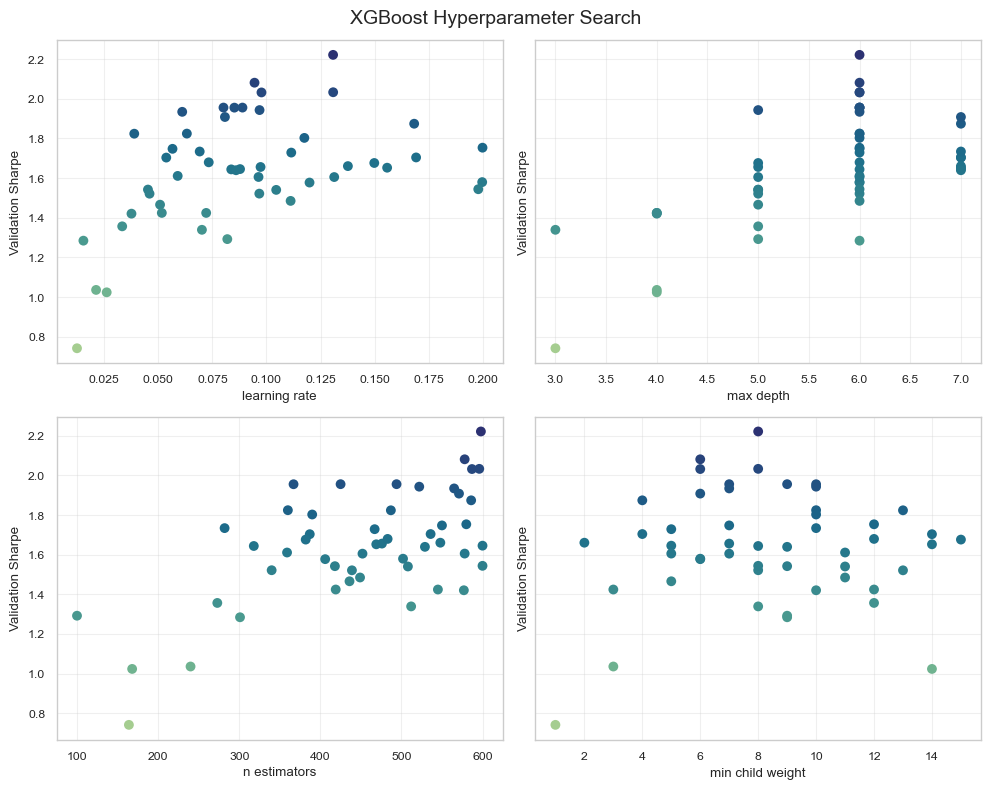

In [8]:
cmap = sns.color_palette("crest", as_cmap=True)
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharey=True)
params = [
    'params_learning_rate',
    'params_max_depth',
    'params_n_estimators',
    'params_min_child_weight'
]

for ax, p in zip(axes.ravel(), params):
    ax.scatter(xgb_trials[p], xgb_trials['value'], c=xgb_trials['value'], cmap=cmap, s=50, alpha=1, edgecolor='none')
    ax.set_xlabel(p.replace('params_', '').replace('_', ' '))
    ax.set_ylabel('Validation Sharpe')
    ax.grid(alpha=0.3)

fig.suptitle('XGBoost Hyperparameter Search', fontsize=14)
fig.tight_layout()
fig.savefig(tree_plots_dir / 'xgb_hyperparameter_scatter.png', dpi=300)
plt.show()
plt.close(fig)

### XGBoost and LightGBM

In [9]:
xgb_ls_df = pd.read_csv(tree_dir / 'xgb_returns_long_short.csv')
xgb_lo_df = pd.read_csv(tree_dir / 'xgb_returns_long_only.csv')
lgb_ls_df = pd.read_csv(tree_dir / 'lgb_returns_long_short.csv')
lgb_lo_df = pd.read_csv(tree_dir / 'lgb_returns_long_only.csv')

xgb_eval = {
    'returns_ls_scaled': xgb_ls_df['return_scaled'].to_numpy(),
    'returns_ls_unscaled': xgb_ls_df['return_unscaled'].to_numpy(),
    'returns_lo_scaled': xgb_lo_df['return_scaled'].to_numpy(),
    'returns_lo_unscaled': xgb_lo_df['return_unscaled'].to_numpy(),
    'leverage_ls': xgb_ls_df['leverage'].to_numpy(),
    'leverage_lo': xgb_lo_df['leverage'].to_numpy(),
}
lgb_eval = {
    'returns_ls_scaled': lgb_ls_df['return_scaled'].to_numpy(),
    'returns_ls_unscaled': lgb_ls_df['return_unscaled'].to_numpy(),
    'returns_lo_scaled': lgb_lo_df['return_scaled'].to_numpy(),
    'returns_lo_unscaled': lgb_lo_df['return_unscaled'].to_numpy(),
    'leverage_ls': lgb_ls_df['leverage'].to_numpy(),
    'leverage_lo': lgb_lo_df['leverage'].to_numpy(),
}

xgb_imp = pd.read_csv(tree_dir / 'xgb_feature_importance.csv').sort_values('importance', ascending=False)
lgb_imp = pd.read_csv(tree_dir / 'lgb_feature_importance.csv').sort_values('importance', ascending=False)

tree_per_year = pd.read_csv(tree_dir / 'tree_per_year_metrics.csv')
tree_summary = pd.read_csv(tree_dir / 'tree_summary.csv')

xgb_study = None
lgb_study = None
try:
    with open(tree_dir / 'xgb_optuna_study.pkl', 'rb') as fh:
        xgb_study = pickle.load(fh)
    with open(tree_dir / 'lgb_optuna_study.pkl', 'rb') as fh:
        lgb_study = pickle.load(fh)
    print('optuna study objects loaded from pickle')
except Exception:
    print('optuna study pickles not available, csv-based hpt plot already shown above')

rebalance_freq = 6
results_dir = Path('plots') / tree_dir.name
results_dir.mkdir(parents=True, exist_ok=True)

print(f'xgb periods: {len(xgb_ls_df)}, lgb periods: {len(lgb_ls_df)}')
print()
print('tree benchmark headline summary')
print(tree_summary.to_string(index=False))

optuna study objects loaded from pickle
xgb periods: 10, lgb periods: 10

tree benchmark headline summary
   model  portfolio  scaling  rc_test  sharpe     se  ann_ret  ann_vol  cagr  cum_return  max_dd  n_obs
 xgboost long_short unscaled   0.1093  1.4408 0.4514    15.76    10.94 15.84      108.55    0.55     10
 xgboost long_short   scaled   0.1093  1.4159 0.4475    13.10     9.25 13.11       85.18    1.64     10
 xgboost  long_only unscaled   0.1093  0.9210 0.3774    11.53    12.52 11.12       69.39    8.82     10
 xgboost  long_only   scaled   0.1093  1.0423 0.3928    10.43    10.00 10.21       62.59    5.63     10
lightgbm long_short unscaled   0.1049  1.3970 0.4445    15.57    11.15 15.61      106.53    1.51     10
lightgbm long_short   scaled   0.1049  1.3410 0.4358    10.89     8.12 10.87       67.52    4.52     10
lightgbm  long_only unscaled   0.1049  0.9218 0.3775    11.60    12.58 11.18       69.89    8.71     10
lightgbm  long_only   scaled   0.1049  1.0443 0.3931    10.42 

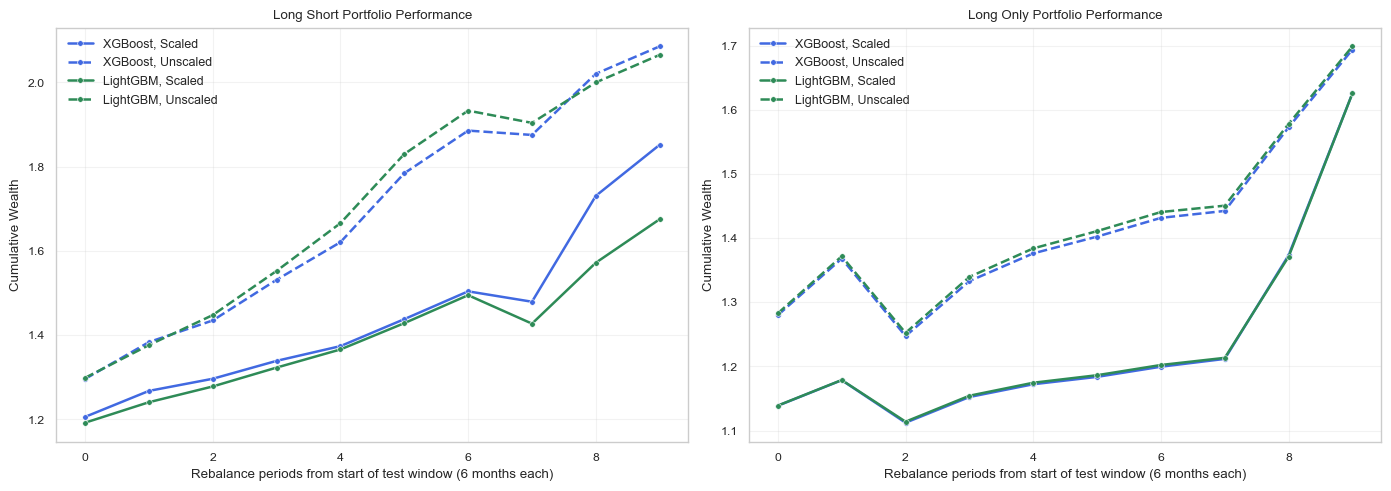

In [10]:
xgb_color = 'royalblue'
lgb_color = 'seagreen'

xlabel_periods = f'Rebalance periods from start of test window ({rebalance_freq} months each)'
marker_style = {'marker': 'o', 'markersize': 4, 'markeredgecolor': 'white', 'markeredgewidth': 0.4}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Long Short
ax = axes[0]

ax.plot(np.cumprod(1 + xgb_eval['returns_ls_scaled']), label='XGBoost, Scaled', color=xgb_color, linewidth=1.8, **marker_style)
ax.plot(np.cumprod(1 + xgb_eval['returns_ls_unscaled']), label='XGBoost, Unscaled', color=xgb_color, linestyle='--', linewidth=1.8, **marker_style)
ax.plot(np.cumprod(1 + lgb_eval['returns_ls_scaled']), label='LightGBM, Scaled', color=lgb_color, linewidth=1.8, **marker_style)
ax.plot(np.cumprod(1 + lgb_eval['returns_ls_unscaled']), label='LightGBM, Unscaled', color=lgb_color, linestyle='--', linewidth=1.8, **marker_style)
ax.set_xlabel(xlabel_periods)
ax.set_ylabel('Cumulative Wealth')
ax.set_title('Long Short Portfolio Performance')
ax.legend(frameon=False, fontsize=9, loc='upper left')
ax.grid(alpha=0.25)


# Long Only
ax = axes[1]
ax.plot(np.cumprod(1 + xgb_eval['returns_lo_scaled']), label='XGBoost, Scaled', color=xgb_color, linewidth=1.8, **marker_style)
ax.plot(np.cumprod(1 + xgb_eval['returns_lo_unscaled']), label='XGBoost, Unscaled', color=xgb_color, linestyle='--', linewidth=1.8, **marker_style)
ax.plot(np.cumprod(1 + lgb_eval['returns_lo_scaled']), label='LightGBM, Scaled', color=lgb_color, linewidth=1.8, **marker_style)
ax.plot(np.cumprod(1 + lgb_eval['returns_lo_unscaled']), label='LightGBM, Unscaled', color=lgb_color, linestyle='--', linewidth=1.8, **marker_style)

ax.set_xlabel(xlabel_periods)
ax.set_ylabel('Cumulative Wealth')
ax.set_title('Long Only Portfolio Performance')
ax.legend(frameon=False, fontsize=9, loc='upper left')
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(results_dir / 'tree_cumulative_combined.png', dpi=300, bbox_inches='tight')

plt.show()
plt.close(fig)

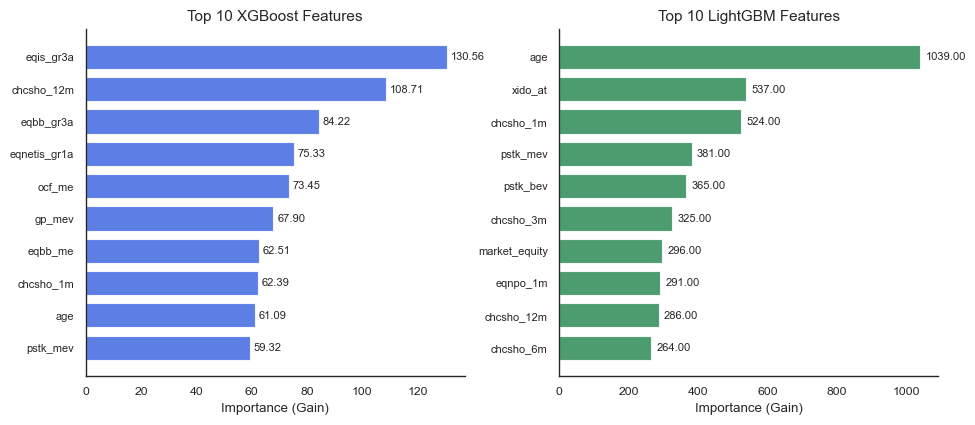

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="white", context="paper")

xgb_color = 'royalblue'
lgb_color = 'seagreen'
top_n = 10

top_xgb = xgb_imp.head(top_n).sort_values('importance')
top_lgb = lgb_imp.head(top_n).sort_values('importance')
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# XGBoost
ax = axes[0]
ax.barh(top_xgb['feature'], top_xgb['importance'], color=xgb_color, alpha=0.85, height=0.75)
for i, v in enumerate(top_xgb['importance']):
    ax.text(v + 1.4, i, f'{v:.2f}', va='center', fontsize=8, ha='left')
ax.set_title('Top 10 XGBoost Features', fontsize=11)
ax.set_xlabel('Importance (Gain)')
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=8)
ax.grid(False)


# LightGBM
ax = axes[1]
ax.barh(top_lgb['feature'], top_lgb['importance'], color=lgb_color, alpha=0.85, height=0.75)
for i, v in enumerate(top_lgb['importance']):
    ax.text(v + 15, i, f'{v:.2f}', va='center', fontsize=8, ha='left')

ax.set_title('Top 10 LightGBM Features', fontsize=11)
ax.set_xlabel('Importance (Gain)')
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=8)
ax.grid(False)
plt.subplots_adjust(wspace=0.25)
sns.despine()
fig.savefig(results_dir / 'tree_feature_importance_side_by_side.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

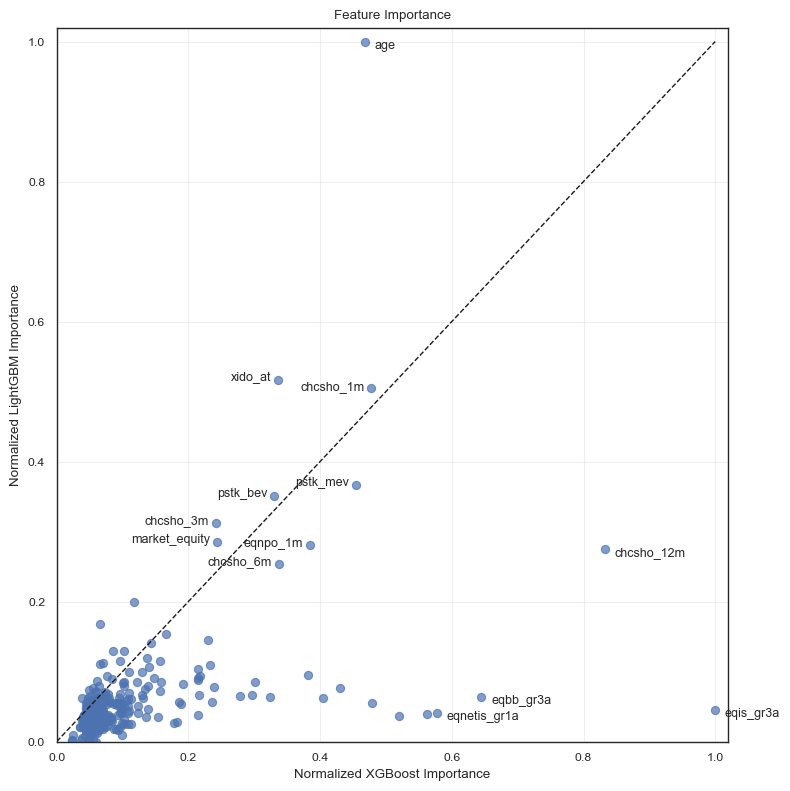

In [12]:
# Merge feature importances
cmp = (
    xgb_imp[['feature', 'importance']].rename(columns={'importance': 'XGBoost'})
    .merge(lgb_imp[['feature', 'importance']]
        .rename(columns={'importance': 'LightGBM'}), on='feature', how='outer'
    ).fillna(0).set_index('feature')
)

# Normalize importances
cmp['XGB'] = cmp['XGBoost'] / cmp['XGBoost'].max()
cmp['LGB'] = cmp['LightGBM'] / cmp['LightGBM'].max()

# Distance from diagonal
cmp['diag_dist'] = np.abs(cmp['XGB'] - cmp['LGB'])

# Label points
outlier_points = cmp.nlargest(5, 'diag_dist')
box_points = cmp[cmp['XGB'].between(0.2, 0.6) & cmp['LGB'].between(0.2, 0.6) ]
label_points = pd.concat([outlier_points, box_points])
label_points = label_points.loc[~label_points.index.duplicated()]

# Scatter plot
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(cmp['XGB'], cmp['LGB'], s=35, alpha=0.7)
ax.plot([0, 1], [0, 1], 'k--', lw=1)

# Label the outliers
for feature, row in outlier_points.iterrows():
    ax.annotate(
        feature,(row['XGB'], row['LGB']),
        xytext=(7, -3), textcoords='offset points',
        fontsize=9,ha='left', va='center'
    )

# Label the points inside the box
for feature, row in box_points.iterrows():
    ax.annotate(
        feature,(row['XGB'], row['LGB']),
        xytext=(-5, -3),textcoords='offset points',
        fontsize=9,ha='right', va='bottom'
    )

ax.set_xlim(0, 1.02)
ax.set_ylim(0, 1.02)

ax.set_xlabel('Normalized XGBoost Importance')
ax.set_ylabel('Normalized LightGBM Importance')
ax.set_title('Feature Importance')
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(results_dir / 'feature_importance_scatter.png', dpi=300)

plt.show()
plt.close(fig)

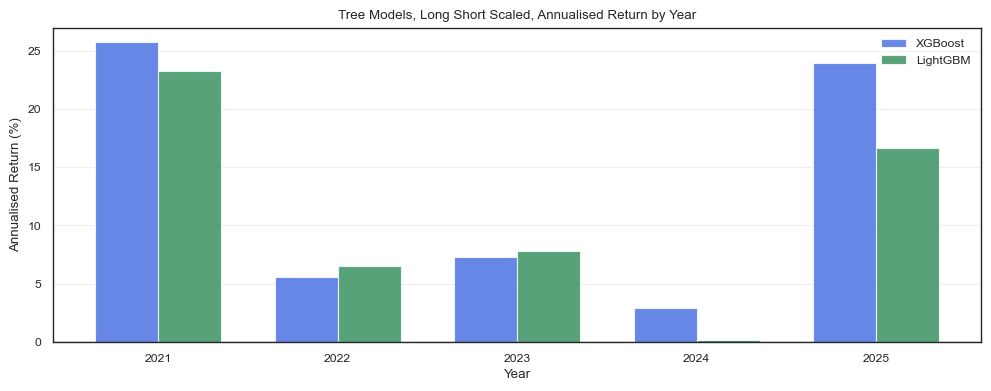

In [13]:
# per year annualised return: xgboost and lightgbm, long-short scaled
years_t = sorted(tree_per_year['year'].unique())
x_t = np.arange(len(years_t))
width_t = 0.35


def _tree_val(model, portfolio, scaling, year, col):
    sub = tree_per_year[
        (tree_per_year['model'] == model) &
        (tree_per_year['portfolio'] == portfolio) &
        (tree_per_year['scaling'] == scaling) &
        (tree_per_year['year'] == year)
    ]
    return float(sub[col].to_numpy()[0]) if len(sub) > 0 else 0.0


xgb_ls_yr = [_tree_val('xgboost', 'long_short', 'scaled', y, 'ann_ret') for y in years_t]
lgb_ls_yr = [_tree_val('lightgbm', 'long_short', 'scaled', y, 'ann_ret') for y in years_t]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x_t - width_t / 2, xgb_ls_yr, width_t, label='XGBoost', color=xgb_color, alpha=0.8)
ax.bar(x_t + width_t / 2, lgb_ls_yr, width_t, label='LightGBM', color=lgb_color, alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x_t)
ax.set_xticklabels([str(y) for y in years_t])
ax.set_xlabel('Year')
ax.set_ylabel('Annualised Return (%)')
ax.set_title('Tree Models, Long Short Scaled, Annualised Return by Year')
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.3)

fig.tight_layout()
fig.savefig(results_dir / 'tree_per_year_bar.png')
plt.show()
plt.close(fig)

#### Prediction Accuracy

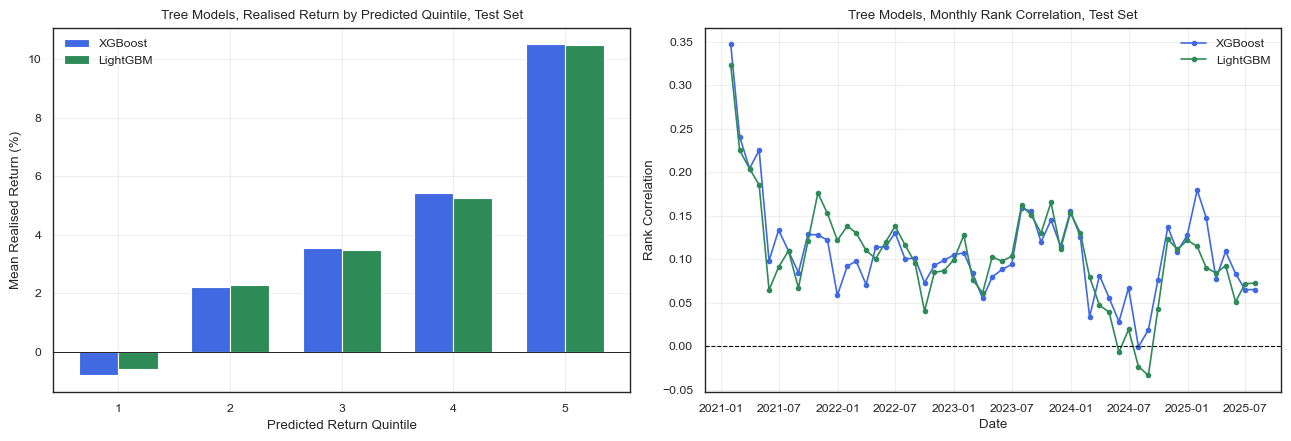

In [14]:
# read the per firm month test set predictions for each tree model.
# each read is defensive, since the exact output of tree_benchmark has
# not been directly verified against the notebook in this session.
def load_tree_predictions(path):
	try:
		df = pd.read_csv(path)
	except FileNotFoundError:
		print(f'{path.name} not found, skipping this diagnostic')
		return None
	df['eom'] = pd.to_datetime(df['eom'])
	return df


def monthly_rank_corr(df):
	rows = []
	for eom, group in df.groupby('eom'):
		valid = group['prediction'].notna() & group['realised_return'].notna()
		if valid.sum() < 10:
			continue
		c = group.loc[valid, 'prediction'].corr(group.loc[valid, 'realised_return'], method = 'spearman')
		rows.append({'eom': eom, 'rank_corr': c})
	return pd.DataFrame(rows).sort_values('eom')


xgb_test_pred = load_tree_predictions(tree_dir / 'xgb_test_predictions.csv')
lgb_test_pred = load_tree_predictions(tree_dir / 'lgb_test_predictions.csv')

if xgb_test_pred is not None and lgb_test_pred is not None:
	xgb_monthly_corr = monthly_rank_corr(xgb_test_pred)
	lgb_monthly_corr = monthly_rank_corr(lgb_test_pred)

	fig, axes = plt.subplots(1, 2, figsize = (13, 4.5))

	def quintile_mean_returns(df):
		def tag(group):
			group = group.copy()
			group['quintile'] = pd.qcut(group['prediction'], 5, labels = False, duplicates = 'drop') + 1
			return group
		tagged = df.groupby('eom', group_keys = False).apply(tag)
		return tagged.groupby('quintile')['realised_return'].mean()

	xgb_quintile_returns = quintile_mean_returns(xgb_test_pred).reindex(range(1, 6))
	lgb_quintile_returns = quintile_mean_returns(lgb_test_pred).reindex(range(1, 6))
	quintile_x = np.arange(1, 6)
	quintile_width = 0.35

	ax = axes[0]
	ax.bar(quintile_x - quintile_width / 2, xgb_quintile_returns.to_numpy() * 100, quintile_width, color = xgb_color, label = 'XGBoost')
	ax.bar(quintile_x + quintile_width / 2, lgb_quintile_returns.to_numpy() * 100, quintile_width, color = lgb_color, label = 'LightGBM')
	ax.axhline(0, color = 'black', linewidth = 0.6)
	ax.set_xticks(quintile_x)
	ax.set_xlabel('Predicted Return Quintile')
	ax.set_ylabel('Mean Realised Return (%)')
	ax.set_title('Tree Models, Realised Return by Predicted Quintile, Test Set')
	ax.legend(frameon = False)
	ax.grid(alpha = 0.3)

	ax = axes[1]
	ax.plot(xgb_monthly_corr['eom'].to_numpy(), xgb_monthly_corr['rank_corr'].to_numpy(), color = xgb_color, marker = 'o', markersize = 3, label = 'XGBoost')
	ax.plot(lgb_monthly_corr['eom'].to_numpy(), lgb_monthly_corr['rank_corr'].to_numpy(), color = lgb_color, marker = 'o', markersize = 3, label = 'LightGBM')
	ax.axhline(0, color = 'black', linewidth = 0.8, linestyle = '--')
	ax.set_xlabel('Date')
	ax.set_ylabel('Rank Correlation')
	ax.set_title('Tree Models, Monthly Rank Correlation, Test Set')
	ax.legend(frameon = False)
	ax.grid(alpha = 0.3)

	fig.tight_layout()
	fig.savefig(results_dir / 'tree_prediction_summary.png')
	plt.show()
	plt.close(fig)


---
## Multi-Layer Perceptron

#### Hyperparameter

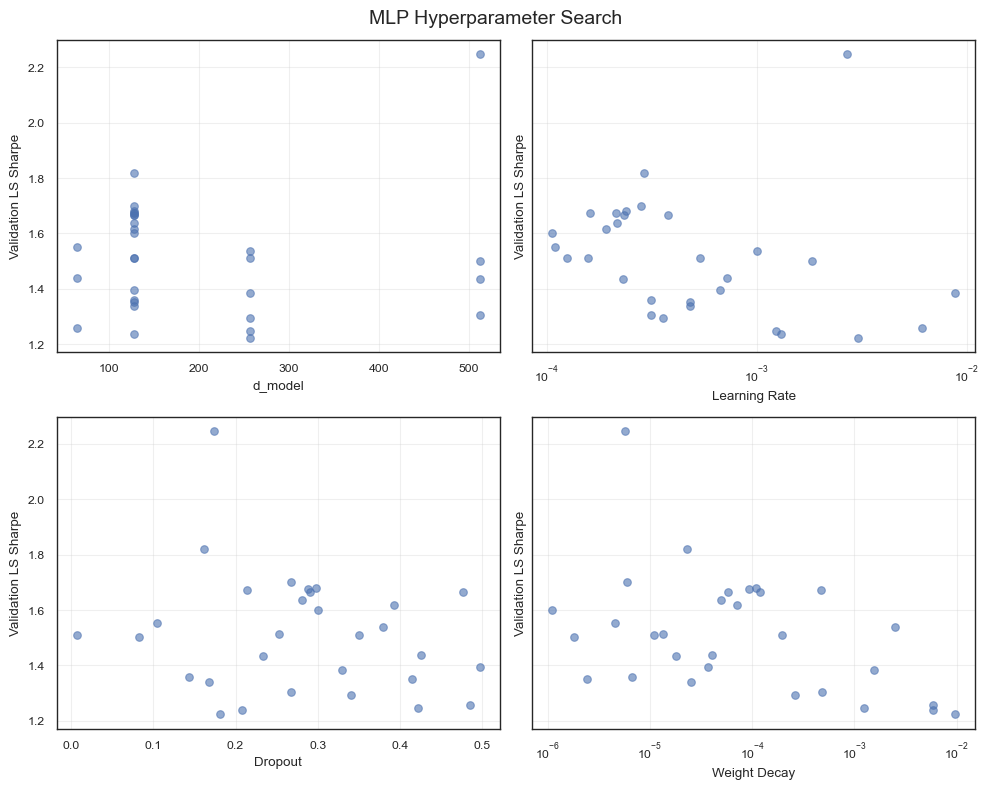

In [15]:
# mlp hpt convergence from saved optuna trials csv
mlp_plots_dir = Path('plots') / mlp_dir.name
mlp_plots_dir.mkdir(parents=True, exist_ok=True)
mlp_trials = pd.read_csv(mlp_dir / 'mlp_optuna_trials.csv')
mlp_color1 = 'C0'
mlp_color2 = 'slategrey'

# MLP hyperparameter search
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharey=True)
params = ['params_d_model', 'params_learning_rate', 'params_dropout', 'params_weight_decay']
labels = ['d_model', 'Learning Rate', 'Dropout', 'Weight Decay']

for ax, p, label in zip(axes.ravel(), params, labels):
    valid = mlp_trials[[p, 'value']].dropna()
    ax.scatter(valid[p].to_numpy(), valid['value'].to_numpy(), alpha=0.6, s=30)
    # Log scale for parameters spanning orders of magnitude
    if p in ['params_learning_rate', 'params_weight_decay']:
        ax.set_xscale('log')
    ax.set_xlabel(label)
    ax.set_ylabel('Validation LS Sharpe')
    ax.grid(alpha=0.3)

fig.suptitle('MLP Hyperparameter Search', fontsize=14)
fig.tight_layout()
fig.savefig(mlp_plots_dir / 'mlp_hyperparameter_scatter.png')
plt.show()
plt.close(fig)

In [16]:
mlp_ls_df = pd.read_csv(mlp_dir / 'mlp_returns_long_short.csv')
mlp_lo_df = pd.read_csv(mlp_dir / 'mlp_returns_long_only.csv')

mlp_eval = {
    'returns_ls_scaled': mlp_ls_df['return_scaled'].to_numpy(),
    'returns_ls_unscaled': mlp_ls_df['return_unscaled'].to_numpy(),
    'returns_lo_scaled': mlp_lo_df['return_scaled'].to_numpy(),
    'returns_lo_unscaled': mlp_lo_df['return_unscaled'].to_numpy(),
    'leverage_ls': mlp_ls_df['leverage'].to_numpy(),
    'leverage_lo': mlp_lo_df['leverage'].to_numpy(),
}

mlp_per_year = pd.read_csv(mlp_dir / 'mlp_per_year_metrics.csv')
mlp_per_period = pd.read_csv(mlp_dir / 'mlp_per_period_metrics.csv')
mlp_per_month = pd.read_csv(mlp_dir / 'mlp_per_month_metrics.csv')
mlp_per_month['eom'] = pd.to_datetime(mlp_per_month['eom'])

with open(mlp_dir / 'mlp_train_log.json') as fh:
    mlp_train_log = json.load(fh)

mlp_summary = pd.read_csv(mlp_dir / 'mlp_summary.csv')

rebalance_freq_mlp = 6
xlabel_periods_mlp = f'Rebalance periods from start of test window ({rebalance_freq_mlp} months each)'
results_dir_mlp = Path('plots') / mlp_dir.name
results_dir_mlp.mkdir(parents=True, exist_ok=True)

print(f'mlp periods: {len(mlp_ls_df)}, monthly rows: {len(mlp_per_month)}')
print(f'train epochs: {len(mlp_train_log["train_losses"])}')
print()
print('mlp benchmark headline summary')
print(mlp_summary.to_string(index=False))

mlp periods: 10, monthly rows: 220
train epochs: 3

mlp benchmark headline summary
model  portfolio  scaling  rc_test  sharpe     se  ann_ret  ann_vol  cagr  cum_return  max_dd  n_obs
  mlp long_short unscaled   0.1287  2.0594 0.5586    10.91     5.30 11.06       68.99    1.20     10
  mlp long_short   scaled   0.1287  1.9472 0.5381    27.71    14.23 28.63      252.08    3.24     10
  mlp  long_only unscaled   0.1287  0.9348 0.3791    11.04    11.81 10.68       66.06    8.65     10
  mlp  long_only   scaled   0.1287  1.0271 0.3908    10.77    10.49 10.53       64.93    6.14     10


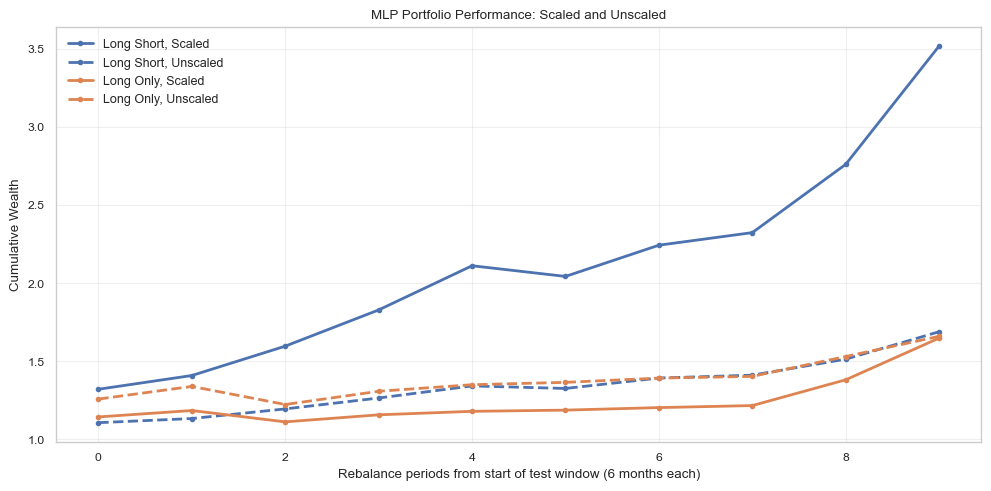

In [17]:
sns.set_theme(style="whitegrid", context="paper")

palette = sns.color_palette("deep", 2)
ls_color = palette[0]
lo_color = palette[1]

fig, ax = plt.subplots(figsize=(10, 5))

ls_scaled = np.cumprod(1 + mlp_eval['returns_ls_scaled'])
ls_unscaled = np.cumprod(1 + mlp_eval['returns_ls_unscaled'])
lo_scaled = np.cumprod(1 + mlp_eval['returns_lo_scaled'])
lo_unscaled = np.cumprod(1 + mlp_eval['returns_lo_unscaled'])

x = np.arange(len(ls_scaled))

ax.plot(x, ls_scaled, label='Long Short, Scaled', color=ls_color, linewidth=2, marker='o', markersize=3)
ax.plot(x, ls_unscaled, label='Long Short, Unscaled', color=ls_color, linestyle='--', linewidth=2, marker='o', markersize=3)

ax.plot(x, lo_scaled, label='Long Only, Scaled', color=lo_color, linewidth=2, marker='o', markersize=3)
ax.plot(x, lo_unscaled, label='Long Only, Unscaled', color=lo_color, linestyle='--', linewidth=2, marker='o', markersize=3)

ax.set_xlabel(xlabel_periods_mlp)
ax.set_ylabel('Cumulative Wealth')
ax.set_title('MLP Portfolio Performance: Scaled and Unscaled')
ax.legend(frameon=False, fontsize=9)
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(results_dir_mlp / 'mlp_cumulative_combined.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

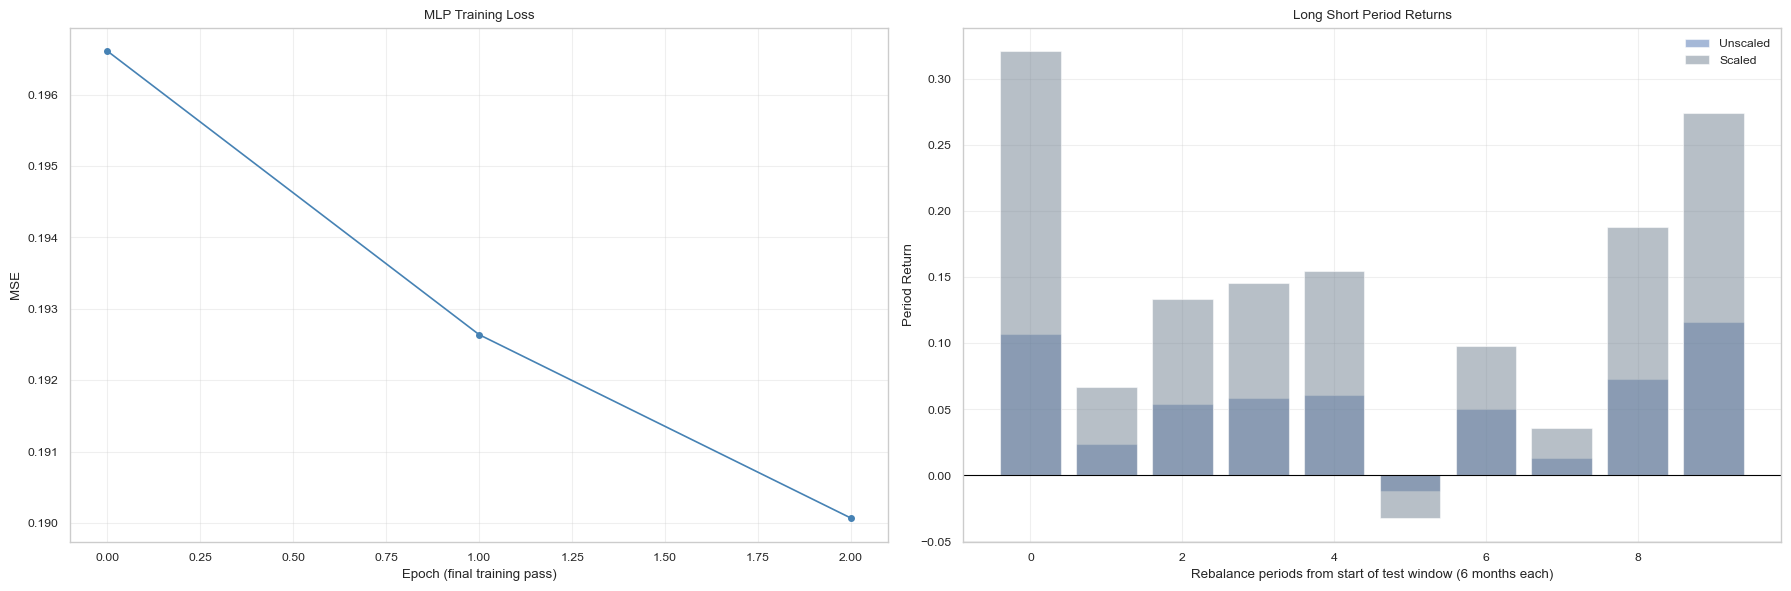

In [18]:
# mlp training loss and long-short period returns
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ax = axes[0]
ax.plot(mlp_train_log['train_losses'], color='steelblue', marker='o', markersize=4)
ax.set_xlabel('Epoch (final training pass)')
ax.set_ylabel('MSE')
ax.set_title('MLP Training Loss')
ax.grid(alpha=0.3)

ax = axes[1]
ls_u = mlp_eval['returns_ls_unscaled']
ls_s = mlp_eval['returns_ls_scaled']
ax.bar(range(len(ls_u)), ls_u, alpha=0.5, color=mlp_color1, label='Unscaled')
ax.bar(range(len(ls_s)), ls_s, alpha=0.5, color=mlp_color2, label='Scaled')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel(xlabel_periods_mlp)
ax.set_ylabel('Period Return')
ax.set_title('Long Short Period Returns')
ax.legend(frameon=False)
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(results_dir_mlp / 'mlp_summary.png')
plt.show()
plt.close(fig)

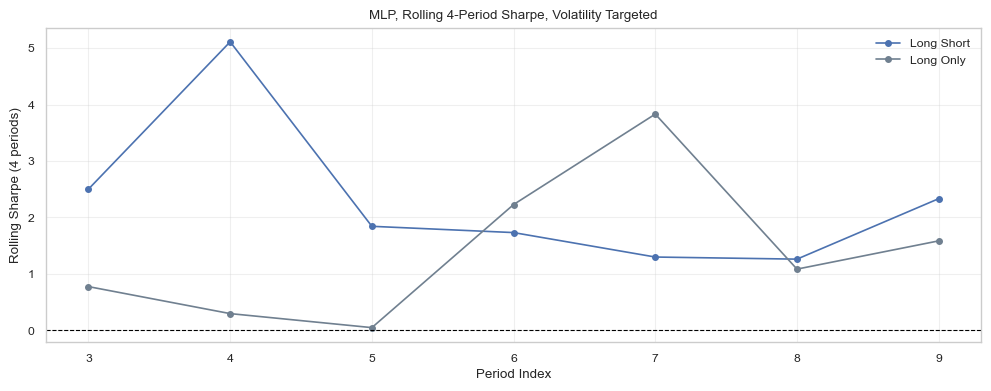

In [39]:
# rolling 4-period sharpe from per-period metrics (covers two calendar years)
mlp_ls_per = mlp_per_period[
    (mlp_per_period['portfolio'] == 'long_short') &
    (mlp_per_period['scaling'] == 'scaled')
].reset_index(drop=True)
mlp_lo_per = mlp_per_period[
    (mlp_per_period['portfolio'] == 'long_only') &
    (mlp_per_period['scaling'] == 'scaled')
].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 4))

valid_ls = mlp_ls_per['rolling_sharpe_4p'].notna()
valid_lo = mlp_lo_per['rolling_sharpe_4p'].notna()

ax.plot(mlp_ls_per.index[valid_ls].to_numpy(), mlp_ls_per.loc[valid_ls, 'rolling_sharpe_4p'].to_numpy(),
        color=mlp_color1, marker='o', markersize=4, label='Long Short')
ax.plot(mlp_lo_per.index[valid_lo].to_numpy(), mlp_lo_per.loc[valid_lo, 'rolling_sharpe_4p'].to_numpy(),
        color=mlp_color2, marker='o', markersize=4, label='Long Only')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Period Index')
ax.set_ylabel('Rolling Sharpe (4 periods)')
ax.set_title('MLP, Rolling 4-Period Sharpe, Volatility Targeted')
ax.legend(frameon=False)
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(results_dir_mlp / 'mlp_rolling_period_sharpe.png')
plt.show()
plt.close(fig)

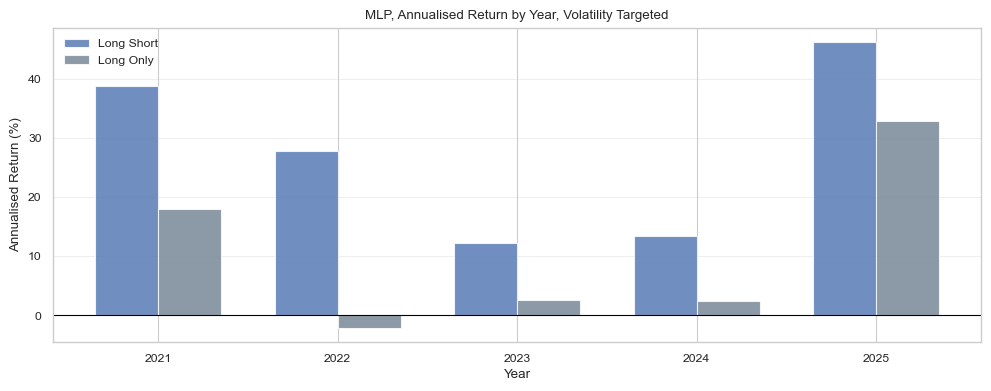

In [20]:
# mlp per year annualised return, long short and long only scaled
years_mlp = sorted(mlp_per_year['year'].unique())
x_mlp = np.arange(len(years_mlp))
width_mlp = 0.35


def _mlp_val(portfolio, year, col):
    sub = mlp_per_year[
        (mlp_per_year['portfolio'] == portfolio) &
        (mlp_per_year['scaling'] == 'scaled') &
        (mlp_per_year['year'] == year)
    ]
    return float(sub[col].to_numpy()[0]) if len(sub) > 0 else 0.0


ls_rets_mlp = [_mlp_val('long_short', y, 'ann_ret') for y in years_mlp]
lo_rets_mlp = [_mlp_val('long_only', y, 'ann_ret') for y in years_mlp]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x_mlp - width_mlp / 2, ls_rets_mlp, width_mlp, label='Long Short', color=mlp_color1, alpha=0.8)
ax.bar(x_mlp + width_mlp / 2, lo_rets_mlp, width_mlp, label='Long Only', color=mlp_color2, alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x_mlp)
ax.set_xticklabels([str(y) for y in years_mlp])
ax.set_xlabel('Year')
ax.set_ylabel('Annualised Return (%)')
ax.set_title('MLP, Annualised Return by Year, Volatility Targeted')
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.3)

fig.tight_layout()
fig.savefig(results_dir_mlp / 'mlp_per_year_bar.png')
plt.show()
plt.close(fig)

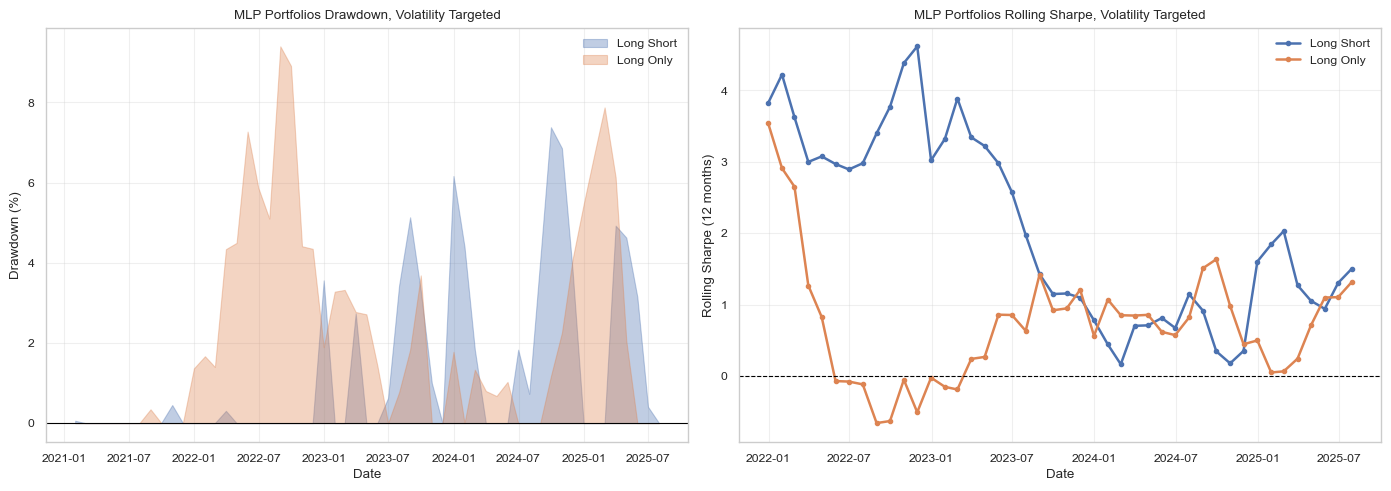

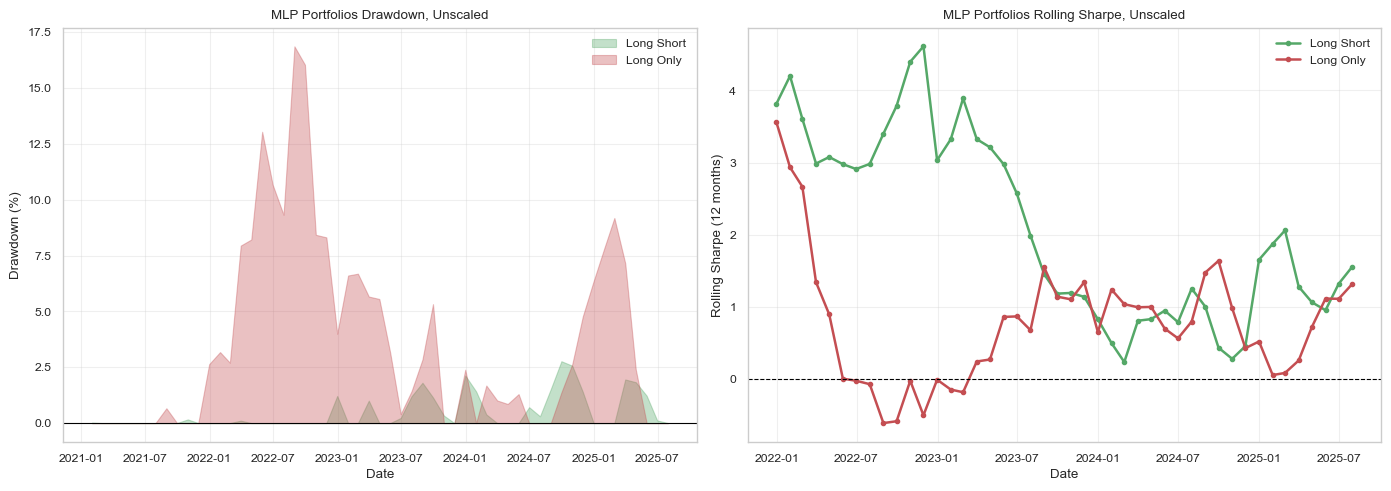

In [21]:
sns.set_theme(style="whitegrid", context="paper")

palette = sns.color_palette("deep", 6)

mlp_ls_mo = mlp_per_month[(mlp_per_month['portfolio'] == 'long_short') & (mlp_per_month['scaling'] == 'scaled')].sort_values('eom')
mlp_lo_mo = mlp_per_month[(mlp_per_month['portfolio'] == 'long_only') & (mlp_per_month['scaling'] == 'scaled')].sort_values('eom')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.fill_between(mlp_ls_mo['eom'], mlp_ls_mo['drawdown'] * 100, color=palette[0], alpha=0.35, label='Long Short')
ax.fill_between(mlp_lo_mo['eom'], mlp_lo_mo['drawdown'] * 100, color=palette[1], alpha=0.35, label='Long Only')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Date')
ax.set_ylabel('Drawdown (%)')
ax.set_title('MLP Portfolios Drawdown, Volatility Targeted')
ax.legend(frameon=False)
ax.grid(alpha=0.3)

ax = axes[1]
valid_ls = mlp_ls_mo['rolling_sharpe_12m'].notna()
valid_lo = mlp_lo_mo['rolling_sharpe_12m'].notna()
ax.plot(mlp_ls_mo.loc[valid_ls, 'eom'], mlp_ls_mo.loc[valid_ls, 'rolling_sharpe_12m'], color=palette[0], linewidth=1.8, marker='o', markersize=3, label='Long Short')
ax.plot(mlp_lo_mo.loc[valid_lo, 'eom'], mlp_lo_mo.loc[valid_lo, 'rolling_sharpe_12m'], color=palette[1], linewidth=1.8, marker='o', markersize=3, label='Long Only')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Date')
ax.set_ylabel('Rolling Sharpe (12 months)')
ax.set_title('MLP Portfolios Rolling Sharpe, Volatility Targeted')
ax.legend(frameon=False)
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(results_dir_mlp / 'mlp_monthly_summary.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)


mlp_ls_mo = mlp_per_month[(mlp_per_month['portfolio'] == 'long_short') & (mlp_per_month['scaling'] == 'unscaled')].sort_values('eom')
mlp_lo_mo = mlp_per_month[(mlp_per_month['portfolio'] == 'long_only') & (mlp_per_month['scaling'] == 'unscaled')].sort_values('eom')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.fill_between(mlp_ls_mo['eom'], mlp_ls_mo['drawdown'] * 100, color=palette[2], alpha=0.35, label='Long Short')
ax.fill_between(mlp_lo_mo['eom'], mlp_lo_mo['drawdown'] * 100, color=palette[3], alpha=0.35, label='Long Only')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Date')
ax.set_ylabel('Drawdown (%)')
ax.set_title('MLP Portfolios Drawdown, Unscaled')
ax.legend(frameon=False)
ax.grid(alpha=0.3)

ax = axes[1]
valid_ls = mlp_ls_mo['rolling_sharpe_12m'].notna()
valid_lo = mlp_lo_mo['rolling_sharpe_12m'].notna()
ax.plot(mlp_ls_mo.loc[valid_ls, 'eom'], mlp_ls_mo.loc[valid_ls, 'rolling_sharpe_12m'], color=palette[2], linewidth=1.8, marker='o', markersize=3, label='Long Short')
ax.plot(mlp_lo_mo.loc[valid_lo, 'eom'], mlp_lo_mo.loc[valid_lo, 'rolling_sharpe_12m'], color=palette[3], linewidth=1.8, marker='o', markersize=3, label='Long Only')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Date')
ax.set_ylabel('Rolling Sharpe (12 months)')
ax.set_title('MLP Portfolios Rolling Sharpe, Unscaled')
ax.legend(frameon=False)
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(results_dir_mlp / 'mlp_monthly_summary_unscaled.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

#### Prediction Accuracy

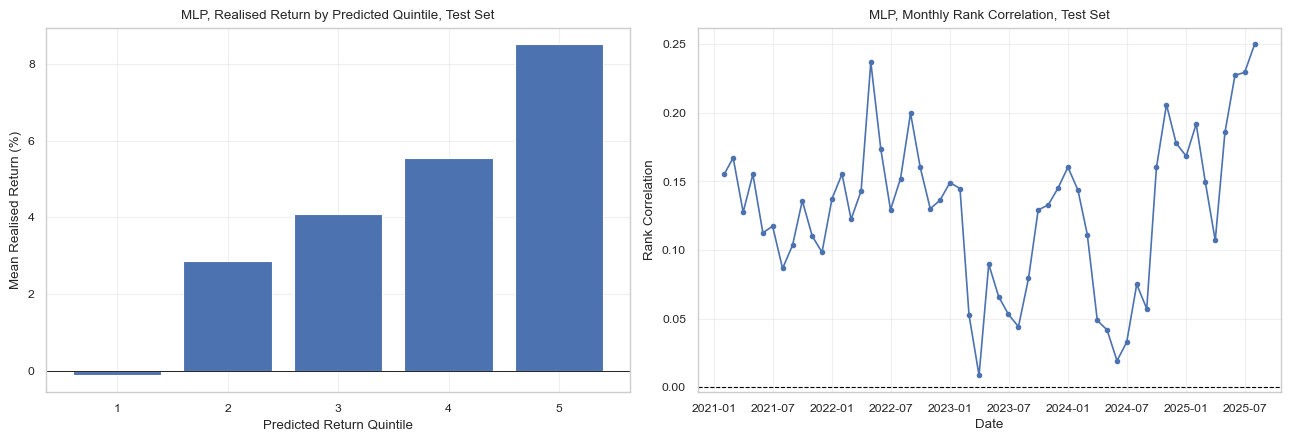

In [22]:
# defensive read of the per firm month test set predictions for the mlp
try:
	mlp_test_pred = pd.read_csv(mlp_dir / 'mlp_test_predictions.csv')
	mlp_test_pred['eom'] = pd.to_datetime(mlp_test_pred['eom'])
except FileNotFoundError:
	mlp_test_pred = None
	print('mlp_test_predictions.csv not found, skipping this diagnostic')

if mlp_test_pred is not None:
	rows = []
	for eom, group in mlp_test_pred.groupby('eom'):
		valid = group['prediction'].notna() & group['realised_return'].notna()
		if valid.sum() < 10:
			continue
		c = group.loc[valid, 'prediction'].corr(group.loc[valid, 'realised_return'], method = 'spearman')
		rows.append({'eom': eom, 'rank_corr': c})
	mlp_monthly_corr = pd.DataFrame(rows).sort_values('eom')

	fig, axes = plt.subplots(1, 2, figsize = (13, 4.5))

	def quintile_mean_returns(df):
		def tag(group):
			group = group.copy()
			group['quintile'] = pd.qcut(group['prediction'], 5, labels = False, duplicates = 'drop') + 1
			return group
		tagged = df.groupby('eom', group_keys = False).apply(tag)
		return tagged.groupby('quintile')['realised_return'].mean()

	mlp_quintile_returns = quintile_mean_returns(mlp_test_pred)

	ax = axes[0]
	ax.bar(mlp_quintile_returns.index.to_numpy(), mlp_quintile_returns.to_numpy() * 100, color = mlp_color1)
	ax.axhline(0, color = 'black', linewidth = 0.6)
	ax.set_xticks(range(1, 6))
	ax.set_xlabel('Predicted Return Quintile')
	ax.set_ylabel('Mean Realised Return (%)')
	ax.set_title('MLP, Realised Return by Predicted Quintile, Test Set')
	ax.grid(alpha = 0.3)

	ax = axes[1]
	ax.plot(mlp_monthly_corr['eom'].to_numpy(), mlp_monthly_corr['rank_corr'].to_numpy(), color = mlp_color1, marker = 'o', markersize = 3)
	ax.axhline(0, color = 'black', linewidth = 0.8, linestyle = '--')
	ax.set_xlabel('Date')
	ax.set_ylabel('Rank Correlation')
	ax.set_title('MLP, Monthly Rank Correlation, Test Set')
	ax.grid(alpha = 0.3)

	fig.tight_layout()
	fig.savefig(results_dir_mlp / 'mlp_prediction_summary.png')
	plt.show()
	plt.close(fig)


---
## FT-Transformer

#### Hyperparameter

In [23]:
ft_dir = Path('results/benchmark/ft_transformer_benchmark')
ft_plots_dir = Path('plots') / ft_dir.name
ft_plots_dir.mkdir(parents=True, exist_ok=True)
ft_color = 'royalblue'

ft_trials = pd.read_csv(ft_dir / 'ft_optuna_trials.csv')

with open(ft_dir / 'ft_best_params.json') as fh:
    ft_best_params_info = json.load(fh)

ft_study = None
try:
    with open(ft_dir / 'ft_optuna_study.pkl', 'rb') as fh:
        ft_study = pickle.load(fh)
    print('optuna study object loaded from pickle')
except Exception:
    print('optuna study pickle not available, csv-based hpt plot used instead')

ua = ft_best_params_info['best_trial_user_attrs']
print('ft-transformer, hyperparameter search summary')
print(f'best trial number, {ft_best_params_info["best_trial_number"]}')
print(f'best val long short sharpe, {ft_best_params_info["best_val_long_short_sharpe"]:.4f}')
print(f'val long only sharpe, {ua.get("val_sharpe_long_only", float("nan")):.4f}')
print(f'best epoch, {ua.get("best_epoch")}, epochs run, {ua.get("n_epochs_run")}')
print(f'd_model, {ua.get("d_model")}, d_ff, {ua.get("d_ff")}, param count, {ua.get("param_count")}')
print(f'best params, {ft_best_params_info["best_params"]}')
print(f'trials completed, {ft_best_params_info["n_trials_completed"]}')

optuna study object loaded from pickle
ft-transformer, hyperparameter search summary
best trial number, 16
best val long short sharpe, 2.7309
val long only sharpe, 0.5966
best epoch, 0, epochs run, 9
d_model, 32, d_ff, 128, param count, 44993
best params, {'n_heads': 4, 'd_model_per_head': 8, 'd_ff_ratio': 4, 'n_layers': 2, 'dropout': 0.251181647470428, 'batch_size': 128, 'learning_rate': 0.0009630619328293385, 'weight_decay': 1.755294192817726e-06}
trials completed, 30


### FT-Transformer

In [24]:
ft_ls_df = pd.read_csv(ft_dir / 'ft_returns_long_short.csv')
ft_lo_df = pd.read_csv(ft_dir / 'ft_returns_long_only.csv')
ft_ls_df['eom'] = pd.to_datetime(ft_ls_df['eom'])
ft_lo_df['eom'] = pd.to_datetime(ft_lo_df['eom'])

ft_holdings_ls = pd.read_csv(ft_dir / 'ft_holdings_long_short.csv')
ft_holdings_lo = pd.read_csv(ft_dir / 'ft_holdings_long_only.csv')

with open(ft_dir / 'ft_train_log.json') as fh:
    ft_train_log = json.load(fh)

ft_summary = pd.read_csv(ft_dir / 'ft_summary.csv')

rebalance_freq_ft = 6
xlabel_periods_ft = f'Rebalance periods from start of test window ({rebalance_freq_ft} months each)'

print(f'ft periods, {len(ft_ls_df)}')
print(f'train epochs, {len(ft_train_log["train_losses"])}')
print('ft-transformer benchmark headline summary')
print(ft_summary.to_string(index=False))

ft periods, 9
train epochs, 11
ft-transformer benchmark headline summary
 portfolio  scaling  rc_test  sharpe     se  ann_ret  ann_vol  cagr  max_dd  n_obs
long_short unscaled   0.1551  2.3589 0.6483    18.30     7.76 18.88    0.00      9
long_short   scaled   0.1551  1.4156 0.4716    31.17    22.02 31.71    0.00      9
 long_only unscaled   0.1551  1.0227 0.4114    14.56    14.24 14.23    7.42      9
 long_only   scaled   0.1551  1.1051 0.4230     9.24     8.36  9.15    4.41      9


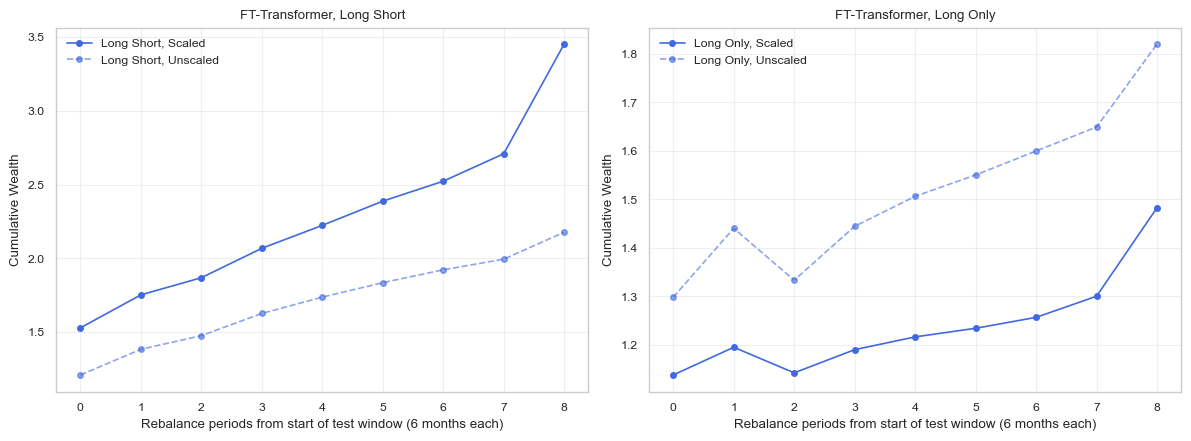

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.plot(np.cumprod(1 + ft_ls_df['return_scaled'].to_numpy()), label='Long Short, Scaled', color=ft_color, marker='o', markersize=4)
ax.plot(np.cumprod(1 + ft_ls_df['return_unscaled'].to_numpy()), label='Long Short, Unscaled', color=ft_color, linestyle='--', alpha=0.6, marker='o', markersize=4)
ax.set_xlabel(xlabel_periods_ft)
ax.set_ylabel('Cumulative Wealth')
ax.set_title('FT-Transformer, Long Short')
ax.legend(frameon=False, loc='upper left')
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(np.cumprod(1 + ft_lo_df['return_scaled'].to_numpy()), label='Long Only, Scaled', color=ft_color, marker='o', markersize=4)
ax.plot(np.cumprod(1 + ft_lo_df['return_unscaled'].to_numpy()), label='Long Only, Unscaled', color=ft_color, linestyle='--', alpha=0.6, marker='o', markersize=4)
ax.set_xlabel(xlabel_periods_ft)
ax.set_ylabel('Cumulative Wealth')
ax.set_title('FT-Transformer, Long Only')
ax.legend(frameon=False, loc='upper left')
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(ft_plots_dir / 'ft_cumulative_wealth.png')
plt.show()
plt.close(fig)

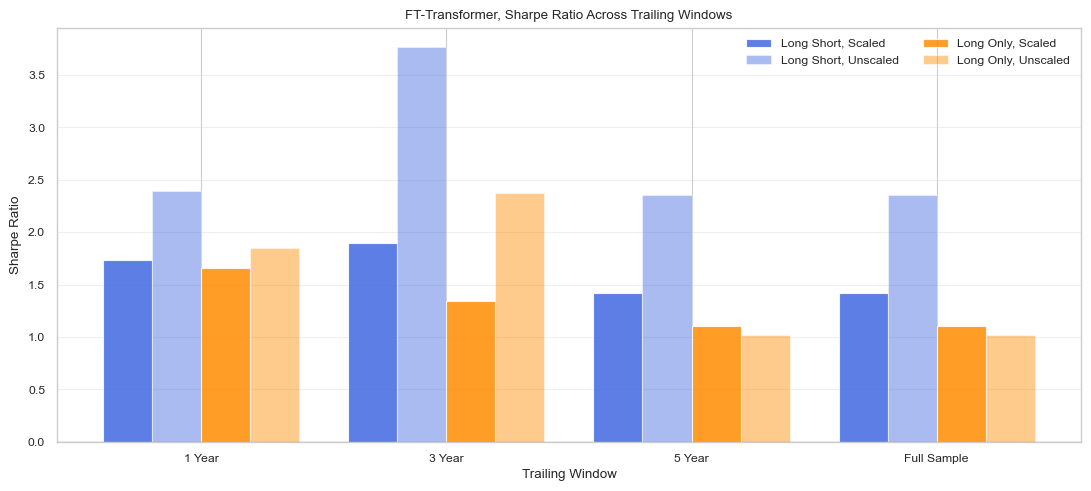

In [26]:
def ft_trailing_sharpe(returns, periods_per_year, n_periods):
	window = returns[-n_periods:] if len(returns) >= n_periods else returns
	if len(window) < 2:
		return float('nan')
	ann_ret = float(np.mean(window) * periods_per_year)
	ann_vol = float(np.std(window, ddof = 1) * np.sqrt(periods_per_year))
	return ann_ret / ann_vol if ann_vol > 0 else float('nan')


ls_scaled_returns = ft_ls_df['return_scaled'].to_numpy()
ls_unscaled_returns = ft_ls_df['return_unscaled'].to_numpy()
lo_scaled_returns = ft_lo_df['return_scaled'].to_numpy()
lo_unscaled_returns = ft_lo_df['return_unscaled'].to_numpy()
periods_per_year_ft = 12.0 / rebalance_freq_ft
window_months_ft = {'sharpe_1y': 12, 'sharpe_3y': 36, 'sharpe_5y': 60}

windows = ['sharpe_1y', 'sharpe_3y', 'sharpe_5y', 'sharpe']
window_labels = ['1 Year', '3 Year', '5 Year', 'Full Sample']
x_ft = np.arange(len(windows))
width_ft = 0.2


def ft_window_periods(key, returns):
	if key == 'sharpe':
		return len(returns)
	return max(1, window_months_ft[key] // rebalance_freq_ft)


ls_scaled_window_vals = [ft_trailing_sharpe(ls_scaled_returns, periods_per_year_ft, ft_window_periods(w, ls_scaled_returns)) for w in windows]
ls_unscaled_window_vals = [ft_trailing_sharpe(ls_unscaled_returns, periods_per_year_ft, ft_window_periods(w, ls_unscaled_returns)) for w in windows]
lo_scaled_window_vals = [ft_trailing_sharpe(lo_scaled_returns, periods_per_year_ft, ft_window_periods(w, lo_scaled_returns)) for w in windows]
lo_unscaled_window_vals = [ft_trailing_sharpe(lo_unscaled_returns, periods_per_year_ft, ft_window_periods(w, lo_unscaled_returns)) for w in windows]

fig, ax = plt.subplots(figsize = (11, 5))
ax.bar(x_ft - 1.5 * width_ft, ls_scaled_window_vals, width_ft, label = 'Long Short, Scaled', color = ft_color, alpha = 0.85)
ax.bar(x_ft - 0.5 * width_ft, ls_unscaled_window_vals, width_ft, label = 'Long Short, Unscaled', color = ft_color, alpha = 0.45)
ax.bar(x_ft + 0.5 * width_ft, lo_scaled_window_vals, width_ft, label = 'Long Only, Scaled', color = 'darkorange', alpha = 0.85)
ax.bar(x_ft + 1.5 * width_ft, lo_unscaled_window_vals, width_ft, label = 'Long Only, Unscaled', color = 'darkorange', alpha = 0.45)
ax.axhline(0, color = 'black', linewidth = 0.8)
ax.set_xticks(x_ft)
ax.set_xticklabels(window_labels)
ax.set_xlabel('Trailing Window')
ax.set_ylabel('Sharpe Ratio')
ax.set_title('FT-Transformer, Sharpe Ratio Across Trailing Windows')
ax.legend(frameon = False, ncol = 2)
ax.grid(axis = 'y', alpha = 0.3)

fig.tight_layout()
fig.savefig(ft_plots_dir / 'ft_trailing_sharpe_windows.png')
plt.show()
plt.close(fig)

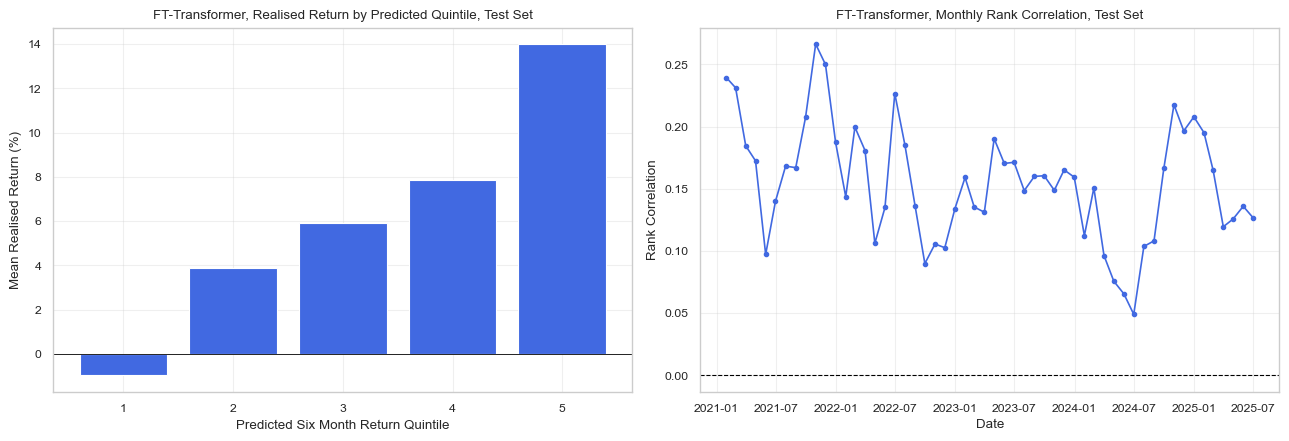

In [27]:
ft_test_pred = pd.read_csv(ft_dir / 'ft_test_predictions.csv')
ft_test_pred['eom'] = pd.to_datetime(ft_test_pred['eom'])

monthly_corr_rows = []
for eom, group in ft_test_pred.groupby('eom'):
	valid = group['prediction'].notna() & group['realised_return'].notna()
	if valid.sum() < 10:
		continue
	c = group.loc[valid, 'prediction'].corr(group.loc[valid, 'realised_return'], method = 'spearman')
	monthly_corr_rows.append({'eom': eom, 'rank_corr': c})
ft_monthly_corr = pd.DataFrame(monthly_corr_rows).sort_values('eom')


def ft_quintile_mean_returns(df):
	def tag(group):
		group = group.copy()
		group['quintile'] = pd.qcut(group['prediction'], 5, labels = False, duplicates = 'drop') + 1
		return group
	tagged = df.groupby('eom', group_keys = False).apply(tag)
	return tagged.groupby('quintile')['realised_return'].mean()


ft_quintile_returns = ft_quintile_mean_returns(ft_test_pred)

fig, axes = plt.subplots(1, 2, figsize = (13, 4.5))

ax = axes[0]
ax.bar(ft_quintile_returns.index.to_numpy(), ft_quintile_returns.to_numpy() * 100, color = ft_color)
ax.axhline(0, color = 'black', linewidth = 0.6)
ax.set_xticks(range(1, 6))
ax.set_xlabel('Predicted Six Month Return Quintile')
ax.set_ylabel('Mean Realised Return (%)')
ax.set_title('FT-Transformer, Realised Return by Predicted Quintile, Test Set')
ax.grid(alpha = 0.3)

ax = axes[1]
ax.plot(ft_monthly_corr['eom'].to_numpy(), ft_monthly_corr['rank_corr'].to_numpy(), color = ft_color, marker = 'o', markersize = 3)
ax.axhline(0, color = 'black', linewidth = 0.8, linestyle = '--')
ax.set_xlabel('Date')
ax.set_ylabel('Rank Correlation')
ax.set_title('FT-Transformer, Monthly Rank Correlation, Test Set')
ax.grid(alpha = 0.3)

fig.tight_layout()
fig.savefig(ft_plots_dir / 'ft_prediction_summary.png')
plt.show()
plt.close(fig)


#### Validation Diagnostics

In [28]:
with open(ft_dir / 'ft_summary.json') as fh:
	ft_summary_full = json.load(fh)

with open(ft_dir / 'ft_splits.json') as fh:
	ft_splits = json.load(fh)

with open(ft_dir / 'ft_feature_cols.json') as fh:
	ft_feature_cols_info = json.load(fh)

ft_val_pred = pd.read_csv(ft_dir / 'ft_val_predictions.csv')
ft_val_pred['eom'] = pd.to_datetime(ft_val_pred['eom'])

ft_arch = ft_summary_full['architecture']
ft_config = ft_summary_full['config']

print('ft-transformer, architecture summary')
print(f'reference, {ft_arch["reference"]}')
print(f'n_heads, {ft_arch["n_heads"]}, d_model, {ft_arch["d_model"]}, d_ff, {ft_arch["d_ff"]}, n_layers, {ft_arch["n_layers"]}, dropout, {ft_arch["dropout"]}')
print(f'parameter count, {ft_arch["parameter_count"]:,}')
print(f'n_features, {ft_feature_cols_info["n_features"]}')
print()
print('ft-transformer, split summary')
print(f'train, {ft_splits["train_start"]} to {ft_splits["train_end"]}, {ft_splits["n_train_months"]} months')
print(f'val, {ft_splits["val_start"]} to {ft_splits["val_end"]}, {ft_splits["n_val_months"]} months')
print(f'test, {ft_splits["test_start"]} to {ft_splits["test_end"]}, {ft_splits["n_test_months"]} months')
print()
print('ft-transformer, portfolio configuration')
print(f'target vol, {ft_config["target_vol"]}, vol lookback months, {ft_config["vol_lookback_months"]}, max position weight, {ft_config["max_position_weight"]}')
print(f'max leverage long only, {ft_config["max_leverage_long_only"]}, max leverage long short, {ft_config["max_leverage_long_short"]}, tc bps, {ft_config["tc_bps"]}')
print()
print(f'final training time seconds, {ft_train_log["training_time_seconds"]:.1f}, parameter count (train log), {ft_train_log["parameter_count"]:,}')
print(f'best val rank corr, {ft_train_log["best_val_rc"]:.4f}, rc_val, {ft_summary_full["ft_transformer"]["rc_val"]:.4f}, rc_test, {ft_summary_full["ft_transformer"]["rc_test"]:.4f}')


ft-transformer, architecture summary
reference, Gorishniy et al. (2021)
n_heads, 4, d_model, 32, d_ff, 128, n_layers, 2, dropout, 0.251181647470428
parameter count, 44,993
n_features, 304

ft-transformer, split summary
train, 1995-01-31 to 2015-12-31, 252 months
val, 2016-01-31 to 2020-12-31, 60 months
test, 2021-01-31 to 2025-06-30, 54 months

ft-transformer, portfolio configuration
target vol, 0.1, vol lookback months, 36, max position weight, 0.05
max leverage long only, 3.0, max leverage long short, 3.0, tc bps, 25

final training time seconds, 604.8, parameter count (train log), 44,993
best val rank corr, 0.1222, rc_val, 0.1222, rc_test, 0.1551


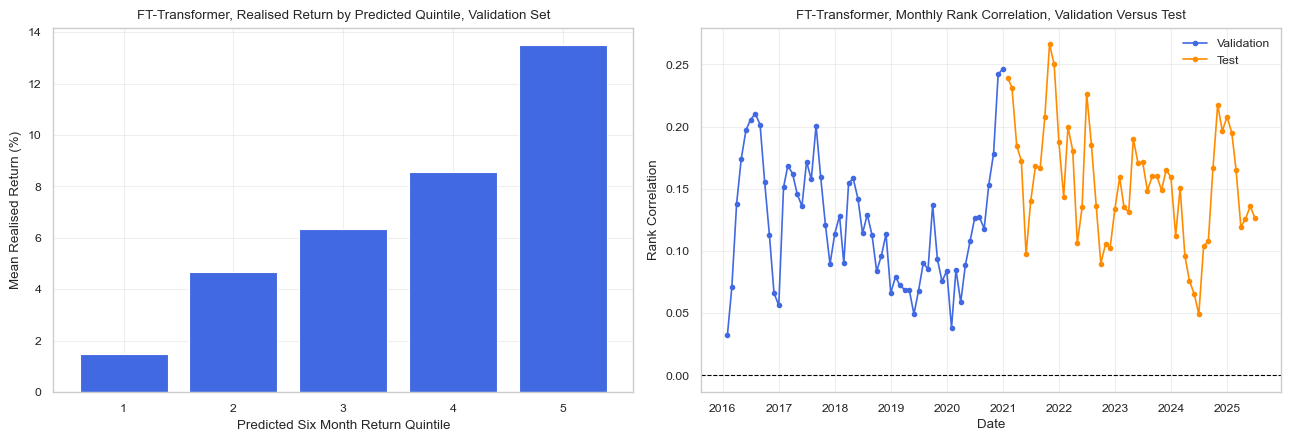

In [29]:
val_monthly_corr_rows = []
for eom, group in ft_val_pred.groupby('eom'):
	valid = group['prediction'].notna() & group['realised_return'].notna()
	if valid.sum() < 10:
		continue
	c = group.loc[valid, 'prediction'].corr(group.loc[valid, 'realised_return'], method = 'spearman')
	val_monthly_corr_rows.append({'eom': eom, 'rank_corr': c})
ft_val_monthly_corr = pd.DataFrame(val_monthly_corr_rows).sort_values('eom')

fig, axes = plt.subplots(1, 2, figsize = (13, 4.5))

ft_val_quintile_returns = ft_quintile_mean_returns(ft_val_pred)

ax = axes[0]
ax.bar(ft_val_quintile_returns.index.to_numpy(), ft_val_quintile_returns.to_numpy() * 100, color = ft_color)
ax.axhline(0, color = 'black', linewidth = 0.6)
ax.set_xticks(range(1, 6))
ax.set_xlabel('Predicted Six Month Return Quintile')
ax.set_ylabel('Mean Realised Return (%)')
ax.set_title('FT-Transformer, Realised Return by Predicted Quintile, Validation Set')
ax.grid(alpha = 0.3)

ax = axes[1]
ax.plot(ft_val_monthly_corr['eom'].to_numpy(), ft_val_monthly_corr['rank_corr'].to_numpy(), color = ft_color, marker = 'o', markersize = 3, label = 'Validation')
ax.plot(ft_monthly_corr['eom'].to_numpy(), ft_monthly_corr['rank_corr'].to_numpy(), color = 'darkorange', marker = 'o', markersize = 3, label = 'Test')
ax.axhline(0, color = 'black', linewidth = 0.8, linestyle = '--')
ax.set_xlabel('Date')
ax.set_ylabel('Rank Correlation')
ax.set_title('FT-Transformer, Monthly Rank Correlation, Validation Versus Test')
ax.legend(frameon = False)
ax.grid(alpha = 0.3)

fig.tight_layout()
fig.savefig(ft_plots_dir / 'ft_validation_prediction_summary.png')
plt.show()
plt.close(fig)


---
## Dual Path Portfolio Transformer

#### Hyperparameter

In [30]:
dppt_hpt_dir = Path('results/transformer/transformer-hpt')
dppt_eval_dir = Path('results/transformer')
dppt_hpt_plots_dir = Path('plots') / dppt_hpt_dir.name
dppt_eval_plots_dir = Path('plots') / dppt_eval_dir.name
dppt_hpt_plots_dir.mkdir(parents=True, exist_ok=True)
dppt_eval_plots_dir.mkdir(parents=True, exist_ok=True)
dppt_variant_order = ['linear', 'per_feature', 'ple', 'periodic', 'fourier']
dppt_color_map = {v: f'C{k}' for k, v in enumerate(dppt_variant_order)}

trans1 = 'royalblue'
trans2 = 'tomato'

master_path = dppt_hpt_dir / 'all_trials_summary.csv'
if master_path.exists():
    dppt_all_trials = pd.read_csv(master_path)
else:
    trial_frames = []
    for variant in dppt_variant_order:
        trial_path = dppt_hpt_dir / f'trials_{variant}.csv'
        if trial_path.exists():
            trial_frames.append(pd.read_csv(trial_path))
    dppt_all_trials = pd.concat(trial_frames, ignore_index=True) if trial_frames else pd.DataFrame()

dppt_best_params = {}
dppt_epoch_history = {}
for variant in dppt_variant_order:
    params_path = dppt_hpt_dir / f'best_params_{variant}.json'
    epoch_path = dppt_hpt_dir / f'epoch_history_{variant}.csv'
    if params_path.exists():
        with open(params_path) as fh:
            dppt_best_params[variant] = json.load(fh)
    if epoch_path.exists():
        dppt_epoch_history[variant] = pd.read_csv(epoch_path)

dppt_variants_hpt = [v for v in dppt_variant_order if v in dppt_best_params]

summary_rows = []
for variant in dppt_variants_hpt:
    p = dppt_best_params[variant]
    summary_rows.append({
        'variant': variant,
        'trial_number': p.get('trial_number'),
        'd_model': p.get('d_model'),
        'n_heads': p.get('n_heads'),
        'n_layers': p.get('n_layers'),
        'lr': round(p.get('lr', float('nan')), 6),
        'best_epoch': p.get('best_epoch'),
        'n_epochs_trained': p.get('n_epochs_trained'),
        'val_sharpe_ls': round(p.get('best_val_sharpe_ls', float('nan')), 4),
        'corr_6m': round(p.get('best_corr_6m', float('nan')), 4),
        'base_corr_6m': round(p.get('best_base_corr_6m', float('nan')), 4),
    })
dppt_hpt_summary = pd.DataFrame(summary_rows)
print('dual path portfolio transformer, hyperparameter search summary')
print(dppt_hpt_summary.to_string(index=False))

dual path portfolio transformer, hyperparameter search summary
    variant  trial_number  d_model n_heads n_layers       lr  best_epoch  n_epochs_trained  val_sharpe_ls  corr_6m  base_corr_6m
     linear             5       64    None     None 0.001662          11                19         2.5478   0.1432        0.1211
per_feature            29       64    None     None 0.000514          17                25         2.9046   0.1195        0.1149
        ple            26       64    None     None 0.000197           9                17         2.6012   0.1102        0.1039
   periodic            37       96    None     None 0.000604          22                30         2.4878   0.1452        0.1180
    fourier             4       96    None     None 0.000229           7                15         2.4550   0.1474        0.1340


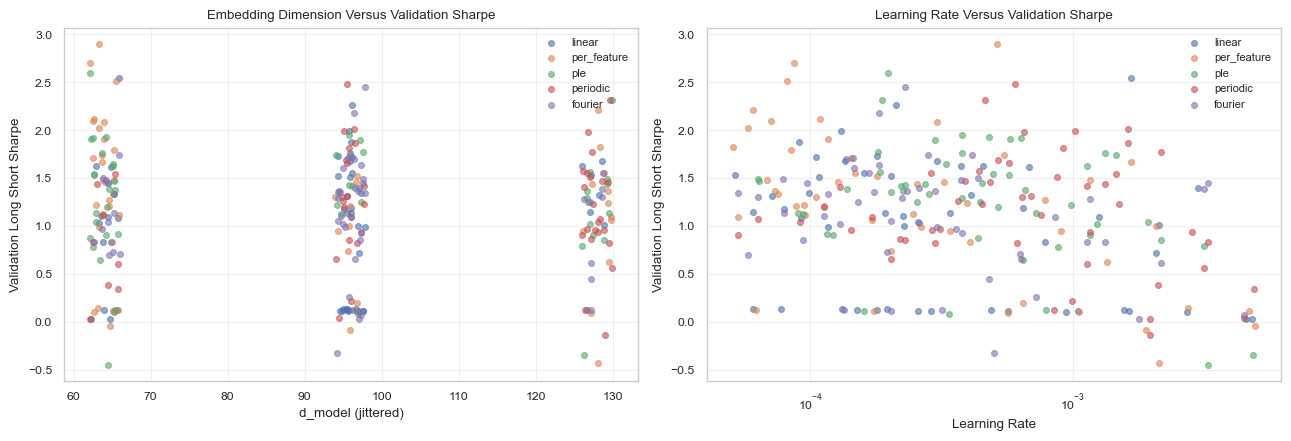

In [31]:
# embedding dimension and learning rate against the optuna objective,
# coloured by encoding variant, across every sampled trial
np.random.seed(7)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for variant in dppt_variants_hpt:
    sub = dppt_all_trials[dppt_all_trials['variant'] == variant]
    sub = sub[sub['value'].notna()]
    if len(sub) == 0:
        continue
    color = dppt_color_map[variant]
    jitter = (np.random.rand(len(sub)) - 0.5) * 4
    axes[0].scatter(sub['params_d_model'].to_numpy() + jitter, sub['value'].to_numpy(), s=18, alpha=0.6, color=color, label=variant)
    axes[1].scatter(sub['params_lr'].to_numpy(), sub['value'].to_numpy(), s=18, alpha=0.6, color=color, label=variant)

axes[0].set_xlabel('d_model (jittered)')
axes[0].set_ylabel('Validation Long Short Sharpe')
axes[0].set_title('Embedding Dimension Versus Validation Sharpe')
handles0, labels0 = axes[0].get_legend_handles_labels()
if len(handles0) > 0:
    axes[0].legend(frameon=False, fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].set_xscale('log')
axes[1].set_xlabel('Learning Rate')
axes[1].set_ylabel('Validation Long Short Sharpe')
axes[1].set_title('Learning Rate Versus Validation Sharpe')
handles1, labels1 = axes[1].get_legend_handles_labels()
if len(handles1) > 0:
    axes[1].legend(frameon=False, fontsize=8)
axes[1].grid(alpha=0.3)

fig.tight_layout()
fig.savefig(dppt_hpt_plots_dir / 'dppt_hyperparameter_scatter.png')
plt.show()
plt.close(fig)

### Portfolio Evaluation

In [32]:
import re as re_dppt

dppt_metrics = {}
seed_pattern_dppt = re_dppt.compile(r'^metrics_(?P<variant>.+)_seed\d+\.json$')
for metrics_path in sorted(dppt_eval_dir.glob('metrics_*.json')):
    if seed_pattern_dppt.match(metrics_path.name):
        continue
    variant = metrics_path.stem[len('metrics_'):]
    with open(metrics_path) as fh:
        dppt_metrics[variant] = json.load(fh)

dppt_variants_eval = [v for v in dppt_variant_order if v in dppt_metrics]

if len(dppt_variants_eval) == 0:
    raise RuntimeError(
        'no metrics_{variant}.json files found under ' + str(dppt_eval_dir) +
        ', run eval_dual_path.py first, this notebook has nothing to plot yet'
    )

comparison_rows = []
monthly_rows = []
for variant in dppt_variants_eval:
    m = dppt_metrics[variant]
    pm = m['portfolio_metrics']
    comparison_rows.append({
        'variant': variant,
        'n_seeds': m.get('ensemble_seed_count'),
        'val_corr': round(m['ensemble_val_rank_corr_6m'], 4),
        'val_sharpe_ls': round(m['validation_portfolio_metrics']['long_short']['sharpe_ratio'], 4),
        'test_corr_6m': round(m['ensemble_test_rank_corr_6m'], 4),
        'sharpe_lo': round(pm['long_only']['sharpe_ratio'], 4),
        'sharpe_lo_u': round(pm['long_only_unscaled']['sharpe_ratio'], 4),
        'sharpe_ls': round(pm['long_short']['sharpe_ratio'], 4),
        'sharpe_ls_u': round(pm['long_short_unscaled']['sharpe_ratio'], 4),
        'vol_ls': round(pm['long_short']['annualised_vol'], 4),
        'vol_ls_u': round(pm['long_short_unscaled']['annualised_vol'], 4),
    })
    monthly_rows.append({
        'variant': variant,
        'sharpe_lo_monthly': round(pm['long_only_monthly']['sharpe_ratio'], 4),
        'sharpe_lo_monthly_u': round(pm['long_only_monthly_unscaled']['sharpe_ratio'], 4),
        'sharpe_ls_monthly': round(pm['long_short_monthly']['sharpe_ratio'], 4),
        'sharpe_ls_monthly_u': round(pm['long_short_monthly_unscaled']['sharpe_ratio'], 4),
    })

dppt_comparison = pd.DataFrame(comparison_rows)
dppt_monthly_comparison = pd.DataFrame(monthly_rows)

dppt_best_variant = max(dppt_variants_eval, key=lambda v: dppt_metrics[v]['ensemble_val_rank_corr_6m'])
dppt_best_sharpe_variant = max(
    dppt_variants_eval,
    key=lambda v: dppt_metrics[v]['validation_portfolio_metrics']['long_short']['sharpe_ratio'],
)

print('dual path portfolio transformer, variant comparison')
print('test set columns are reported, validation set columns are the selection criteria')
print(dppt_comparison.to_string(index=False))
print()
print('monthly frequency sharpe ratios, 6m rebalance, target_1m monthly returns')
print(dppt_monthly_comparison.to_string(index=False))
print()
print(f'best variant by validation rank correlation, {dppt_best_variant}')
print(f'best variant by validation long short sharpe, {dppt_best_sharpe_variant}')

dual path portfolio transformer, variant comparison
test set columns are reported, validation set columns are the selection criteria
    variant  n_seeds  val_corr  val_sharpe_ls  test_corr_6m  sharpe_lo  sharpe_lo_u  sharpe_ls  sharpe_ls_u  vol_ls  vol_ls_u
     linear        5    0.1335         1.2780        0.1059     1.6282       1.5629     2.2067       2.1278  0.1091    0.3187
per_feature        5    0.1273         1.3586        0.0973     1.9354       1.6187     1.9506       1.8571  0.1129    0.3454
        ple        5    0.1122         1.3184        0.1196     1.7884       1.5785     2.0595       1.9817  0.1230    0.3765
   periodic        5    0.1414         1.0714        0.1151     2.2834       1.7792     1.9635       1.9609  0.1299    0.3899
    fourier        5    0.1139         0.4994        0.0926     0.6782       0.6782     1.0494       1.0494  0.2232    0.6695

monthly frequency sharpe ratios, 6m rebalance, target_1m monthly returns
    variant  sharpe_lo_monthly  sharp

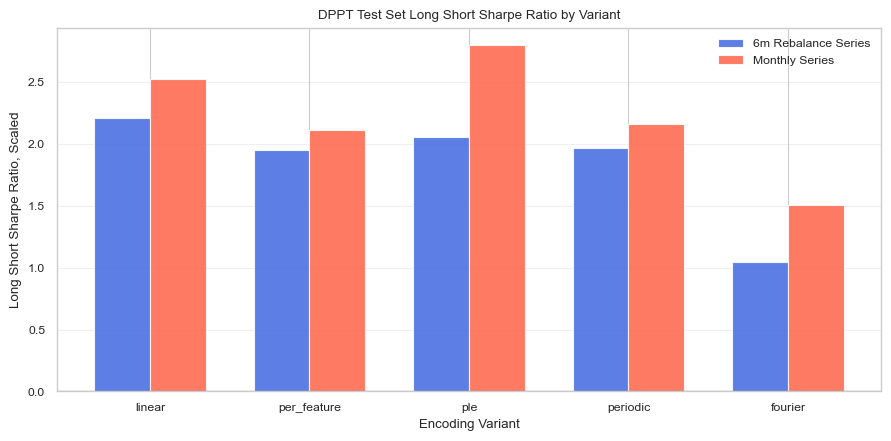

In [33]:
x_e = np.arange(len(dppt_variants_eval))
width_e = 0.35
ls_vals = dppt_comparison['sharpe_ls'].to_numpy()
ls_monthly_vals = dppt_monthly_comparison['sharpe_ls_monthly'].to_numpy()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(x_e - width_e / 2, ls_vals, width_e, label='6m Rebalance Series', color=trans1, alpha=0.85)
ax.bar(x_e + width_e / 2, ls_monthly_vals, width_e, label='Monthly Series', color=trans2, alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x_e)
ax.set_xticklabels(dppt_variants_eval)
ax.set_xlabel('Encoding Variant')
ax.set_ylabel('Long Short Sharpe Ratio, Scaled')
ax.set_title('DPPT Test Set Long Short Sharpe Ratio by Variant')
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.3)

fig.tight_layout()
fig.savefig(dppt_eval_plots_dir / 'dppt_test_sharpe_by_variant.png')
plt.show()
plt.close(fig)

#### Prediction Accuracy

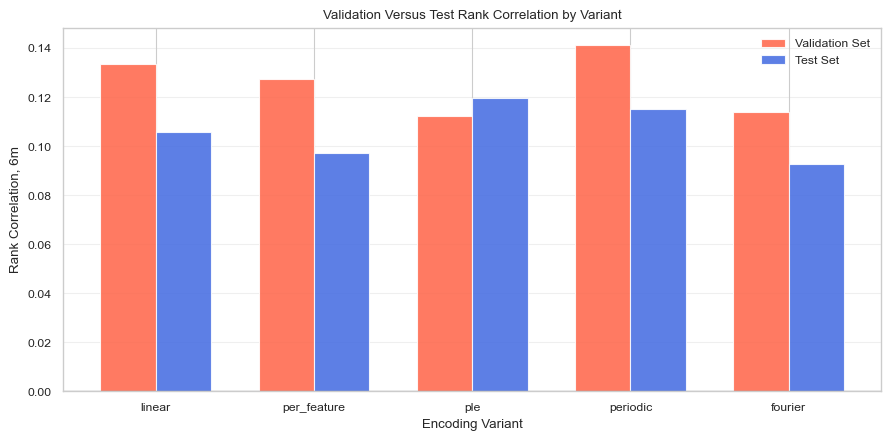

In [34]:
val_corrs = dppt_comparison['val_corr'].to_numpy()
test_corrs = dppt_comparison['test_corr_6m'].to_numpy()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(x_e - width_e / 2, val_corrs, width_e, label='Validation Set', color=trans2, alpha=0.85)
ax.bar(x_e + width_e / 2, test_corrs, width_e, label='Test Set', color=trans1, alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x_e)
ax.set_xticklabels(dppt_variants_eval)
ax.set_xlabel('Encoding Variant')
ax.set_ylabel('Rank Correlation, 6m')
ax.set_title('Validation Versus Test Rank Correlation by Variant')
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.3)

fig.tight_layout()
fig.savefig(dppt_eval_plots_dir / 'dppt_val_vs_test_corr.png')
plt.show()
plt.close(fig)

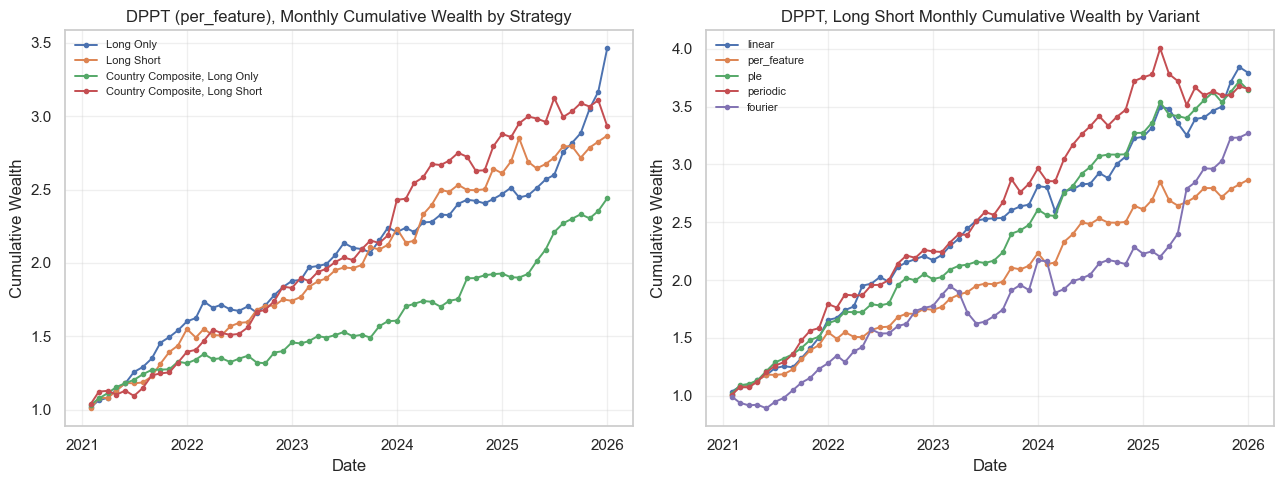

In [43]:
sns.set_theme(style="whitegrid")

marker_style = {'marker': 'o', 'markersize': 3}

dppt_per_month = pd.read_csv(dppt_eval_dir / f'per_month_{dppt_best_sharpe_variant}.csv')
dppt_per_month['eom'] = pd.to_datetime(dppt_per_month['eom'])

dppt_strategy_order = [
    'long_only', 'long_short',
    'country_composite_long_only', 'country_composite_long_short',
]
dppt_strategy_labels = {
    'long_only': 'Long Only',
    'long_short': 'Long Short',
    'country_composite_long_only': 'Country Composite, Long Only',
    'country_composite_long_short': 'Country Composite, Long Short',
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for k, strategy in enumerate(dppt_strategy_order):
    sub = dppt_per_month[
        (dppt_per_month['strategy'] == strategy) &
        (dppt_per_month['scaling'] == 'scaled')
    ].sort_values('eom')
    if len(sub) == 0:
        continue
    ax.plot(sub['eom'].to_numpy(), sub['cumulative_wealth'].to_numpy(), color=f'C{k}', linewidth=1.4, label=dppt_strategy_labels[strategy], **marker_style)
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Wealth')
ax.set_title(f'DPPT ({dppt_best_sharpe_variant}), Monthly Cumulative Wealth by Strategy')
ax.legend(frameon=False, fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1]
for variant in dppt_variants_eval:
    pm_path = dppt_eval_dir / f'per_month_{variant}.csv'
    if not pm_path.exists():
        continue
    pm_v = pd.read_csv(pm_path)
    sub_v = pm_v[(pm_v['strategy'] == 'long_short') & (pm_v['scaling'] == 'scaled')].sort_values('eom')
    if len(sub_v) == 0:
        continue
    ax.plot(pd.to_datetime(sub_v['eom']).to_numpy(), sub_v['cumulative_wealth'].to_numpy(), color=dppt_color_map[variant], linewidth=1.4, label=variant, **marker_style)
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Wealth')
ax.set_title('DPPT, Long Short Monthly Cumulative Wealth by Variant')
ax.legend(frameon=False, fontsize=8)
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(dppt_eval_plots_dir / f'dppt_{dppt_best_sharpe_variant}_cumulative_wealth_monthly.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

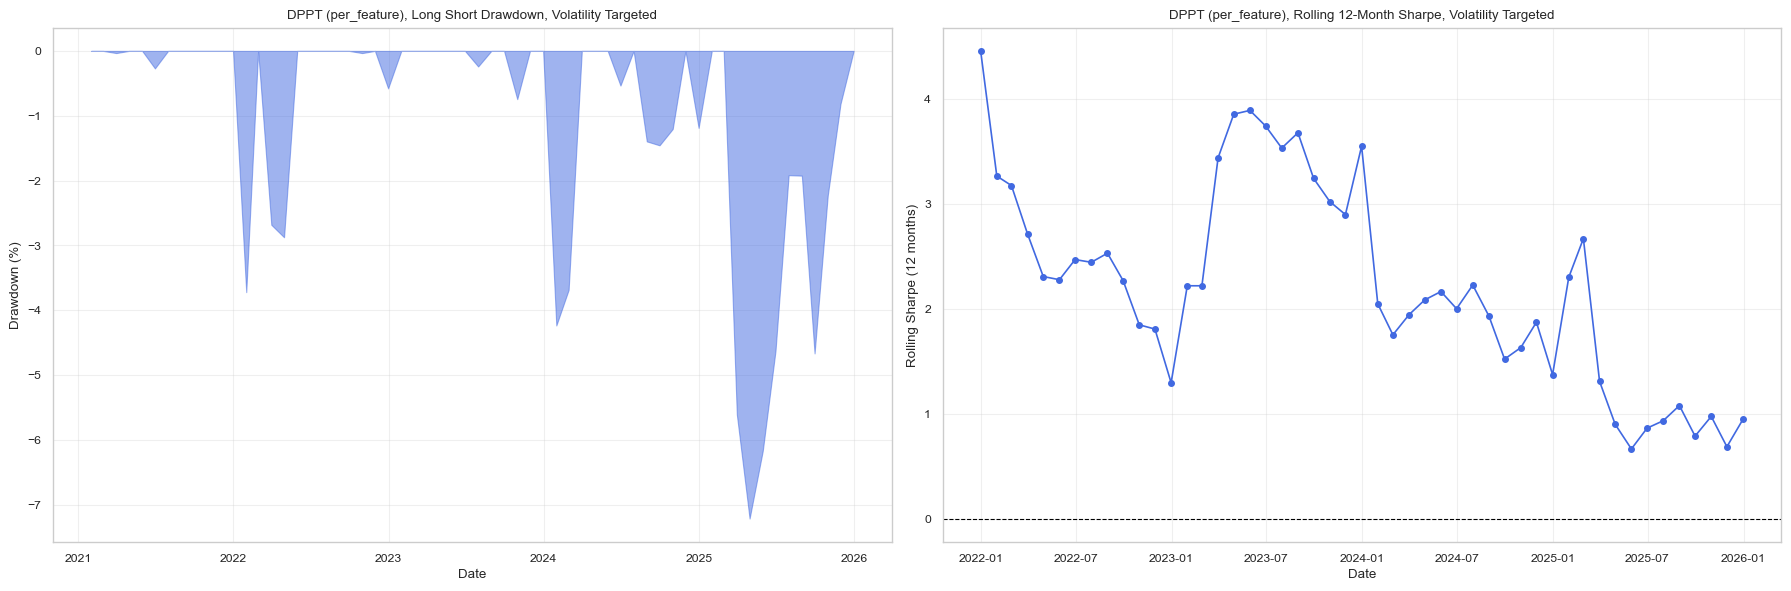

In [41]:
dppt_ls_mo = dppt_per_month[
    (dppt_per_month['strategy'] == 'long_short') &
    (dppt_per_month['scaling'] == 'scaled')
].sort_values('eom')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ax = axes[0]
ax.fill_between(dppt_ls_mo['eom'].to_numpy(), dppt_ls_mo['drawdown'].to_numpy() * 100, alpha=0.5, color=trans1)
ax.set_xlabel('Date')
ax.set_ylabel('Drawdown (%)')
ax.set_title(f'DPPT ({dppt_best_sharpe_variant}), Long Short Drawdown, Volatility Targeted')
ax.grid(alpha=0.3)

ax = axes[1]
valid_s = dppt_ls_mo['rolling_sharpe_12m'].notna()
ax.plot(dppt_ls_mo.loc[valid_s, 'eom'].to_numpy(), dppt_ls_mo.loc[valid_s, 'rolling_sharpe_12m'].to_numpy(), color=trans1, marker='o', markersize=4)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Date')
ax.set_ylabel('Rolling Sharpe (12 months)')
ax.set_title(f'DPPT ({dppt_best_sharpe_variant}), Rolling 12-Month Sharpe, Volatility Targeted')
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(dppt_eval_plots_dir / f'dppt_{dppt_best_sharpe_variant}_rolling_summary.png')
plt.show()
plt.close(fig)

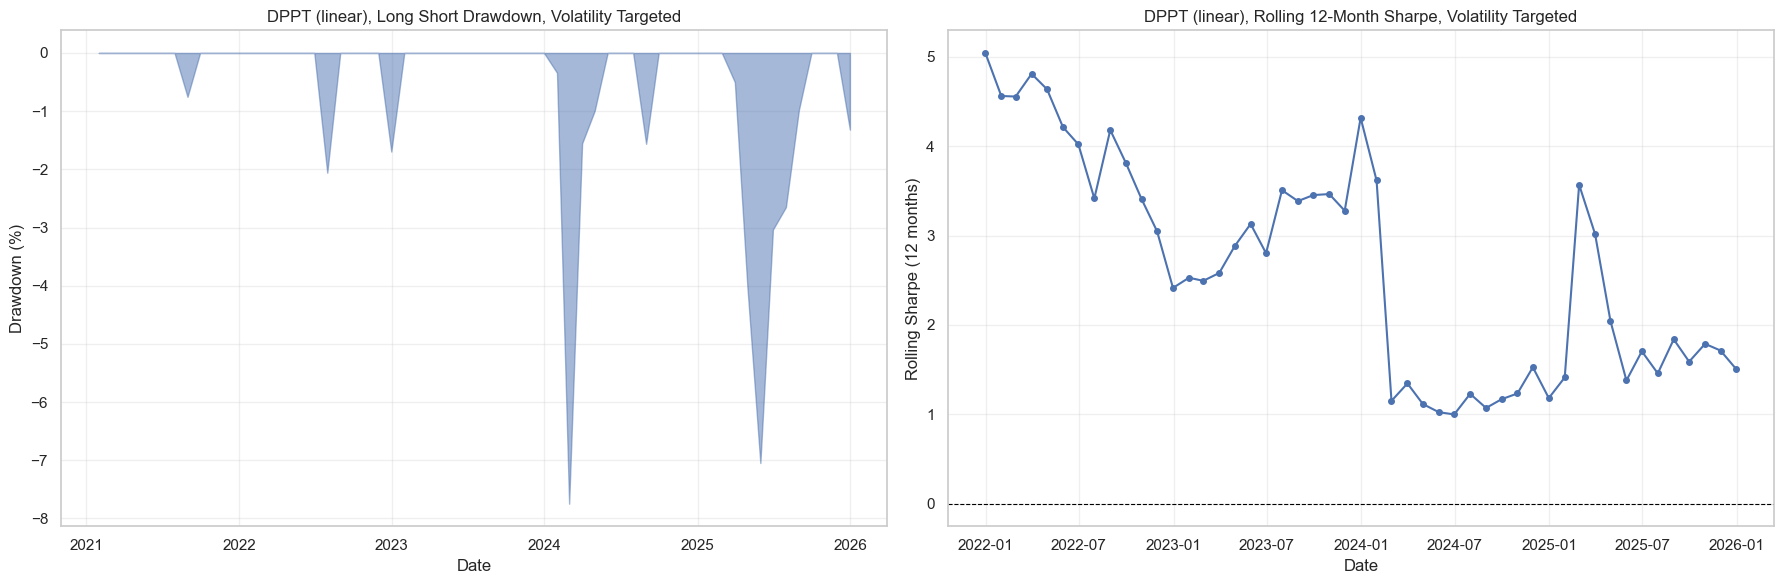

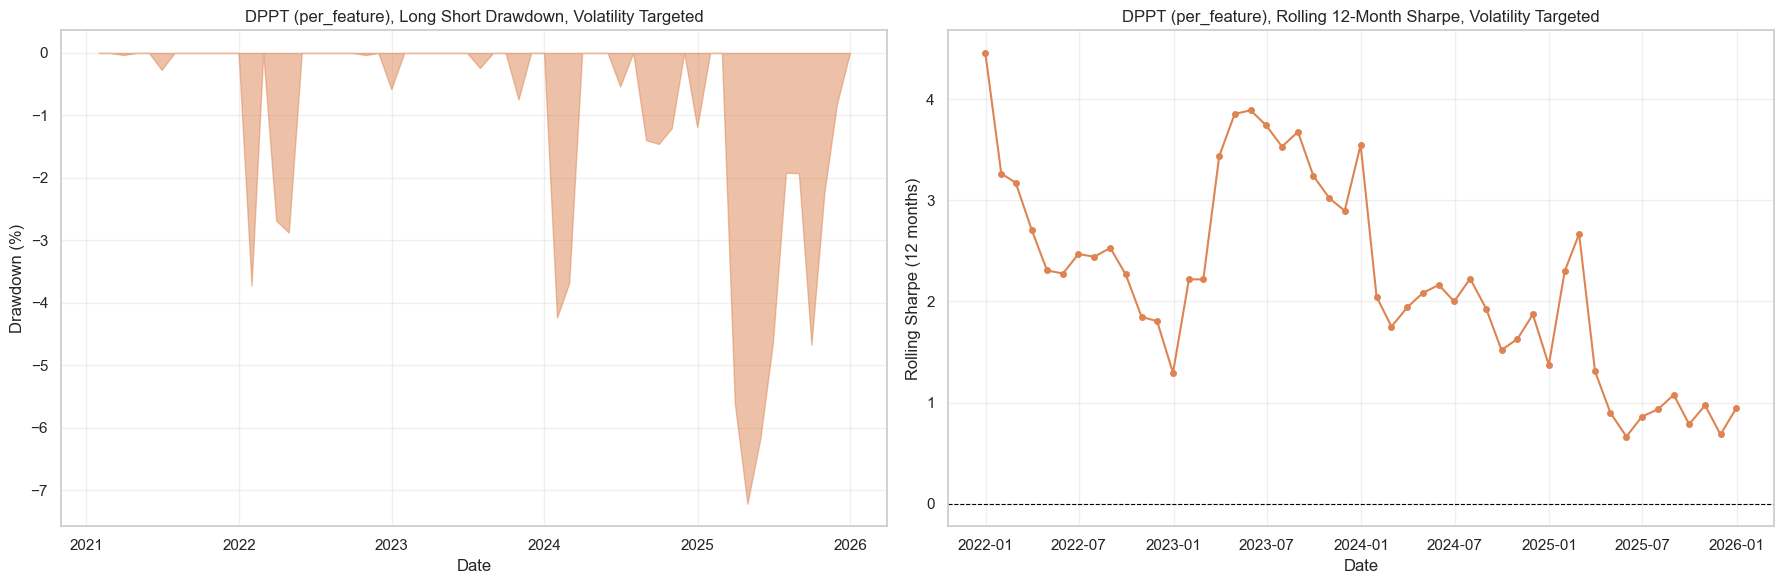

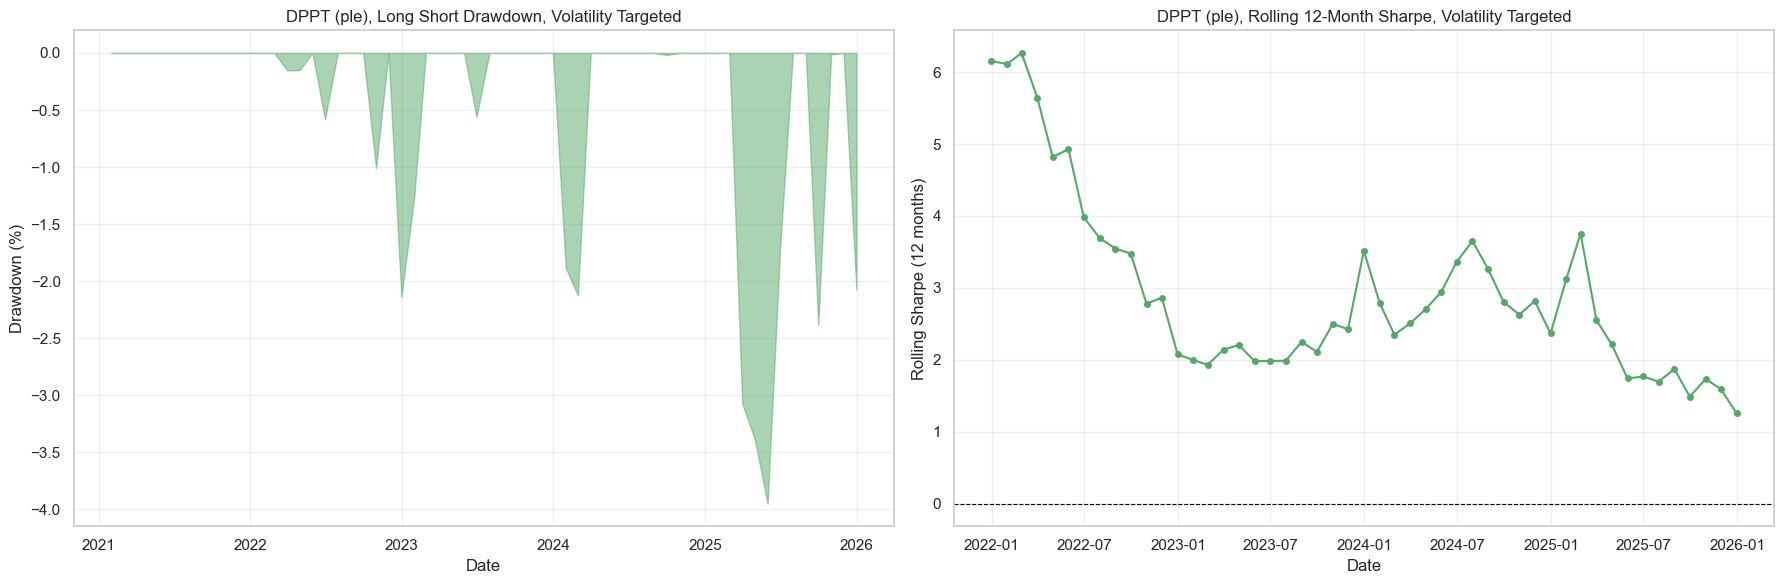

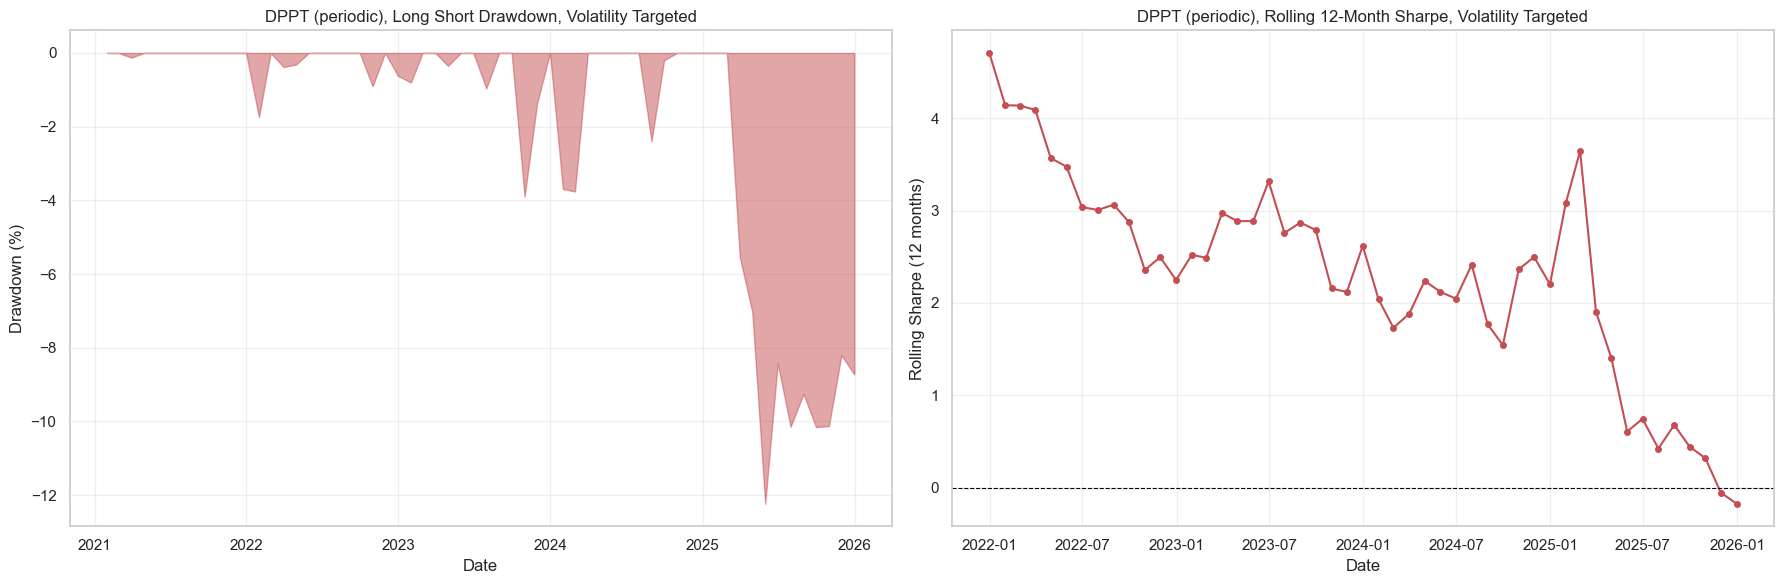

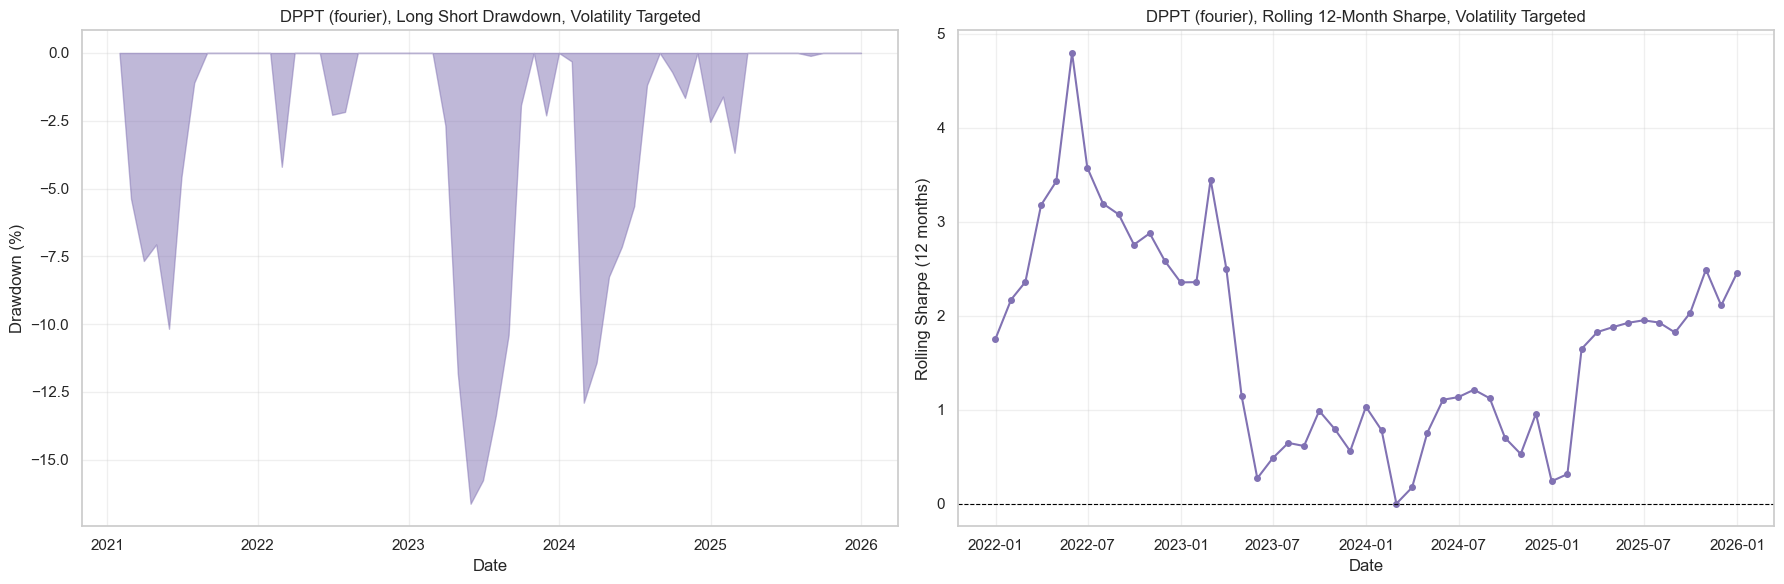

In [44]:
for variant in dppt_variants_eval:
    pm_path = dppt_eval_dir / f'per_month_{variant}.csv'
    if not pm_path.exists():
        continue
    pm_v = pd.read_csv(pm_path)
    pm_v['eom'] = pd.to_datetime(pm_v['eom'])

    ls_mo = pm_v[
        (pm_v['strategy'] == 'long_short') &
        (pm_v['scaling'] == 'scaled')
    ].sort_values('eom')
    if len(ls_mo) == 0:
        continue

    color = dppt_color_map[variant]

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    ax = axes[0]
    ax.fill_between(ls_mo['eom'].to_numpy(), ls_mo['drawdown'].to_numpy() * 100, alpha=0.5, color=color)
    ax.set_xlabel('Date')
    ax.set_ylabel('Drawdown (%)')
    ax.set_title(f'DPPT ({variant}), Long Short Drawdown, Volatility Targeted')
    ax.grid(alpha=0.3)

    ax = axes[1]
    valid_s = ls_mo['rolling_sharpe_12m'].notna()
    ax.plot(ls_mo.loc[valid_s, 'eom'].to_numpy(), ls_mo.loc[valid_s, 'rolling_sharpe_12m'].to_numpy(), color=color, marker='o', markersize=4)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Date')
    ax.set_ylabel('Rolling Sharpe (12 months)')
    ax.set_title(f'DPPT ({variant}), Rolling 12-Month Sharpe, Volatility Targeted')
    ax.grid(alpha=0.3)

    fig.tight_layout()
    fig.savefig(dppt_eval_plots_dir / f'dppt_{variant}_rolling_summary.png')
    plt.show()
    plt.close(fig)

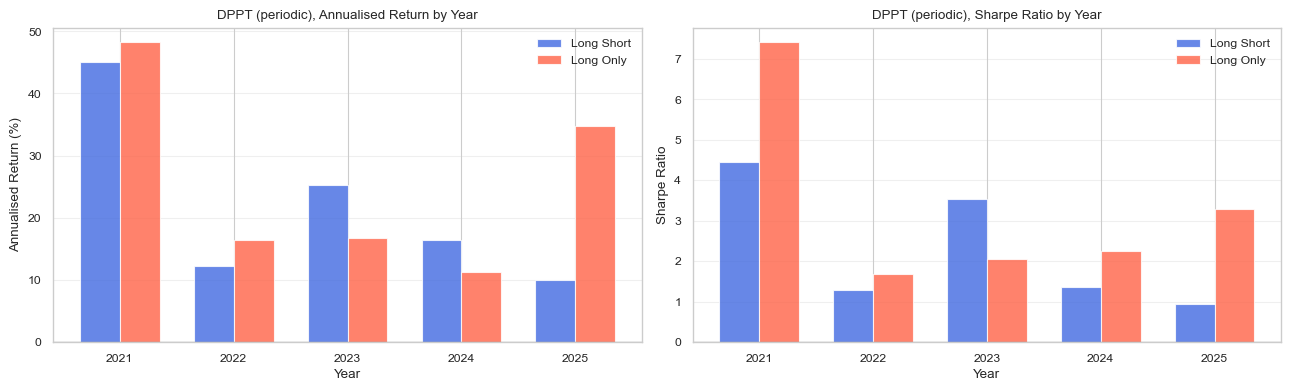

In [37]:
dppt_per_year = pd.read_csv(dppt_eval_dir / f'per_year_{dppt_best_sharpe_variant}.csv')

dppt_py = dppt_per_year[
    (dppt_per_year['strategy'].isin(['long_short_monthly', 'long_only_monthly'])) &
    (dppt_per_year['scaling'] == 'scaled')
]

years_dppt = sorted(dppt_py['year'].unique())
x_dppt = np.arange(len(years_dppt))
width_dppt = 0.35


def _dppt_val(strategy, year, col):
    sub = dppt_py[(dppt_py['strategy'] == strategy) & (dppt_py['year'] == year)]
    return float(sub[col].to_numpy()[0]) if len(sub) > 0 else float('nan')


ls_yr = [_dppt_val('long_short_monthly', y, 'ann_ret') for y in years_dppt]
lo_yr = [_dppt_val('long_only_monthly', y, 'ann_ret') for y in years_dppt]
ls_sharpe_yr = [_dppt_val('long_short_monthly', y, 'sharpe') for y in years_dppt]
lo_sharpe_yr = [_dppt_val('long_only_monthly', y, 'sharpe') for y in years_dppt]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.bar(x_dppt - width_dppt / 2, ls_yr, width_dppt, label='Long Short', color=trans1, alpha=0.8)
ax.bar(x_dppt + width_dppt / 2, lo_yr, width_dppt, label='Long Only', color=trans2, alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x_dppt)
ax.set_xticklabels([str(y) for y in years_dppt])
ax.set_xlabel('Year')
ax.set_ylabel('Annualised Return (%)')
ax.set_title(f'DPPT ({dppt_best_variant}), Annualised Return by Year')
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
ax.bar(x_dppt - width_dppt / 2, ls_sharpe_yr, width_dppt, label='Long Short', color=trans1, alpha=0.8)
ax.bar(x_dppt + width_dppt / 2, lo_sharpe_yr, width_dppt, label='Long Only', color=trans2, alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x_dppt)
ax.set_xticklabels([str(y) for y in years_dppt])
ax.set_xlabel('Year')
ax.set_ylabel('Sharpe Ratio')
ax.set_title(f'DPPT ({dppt_best_variant}), Sharpe Ratio by Year')
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.3)

fig.tight_layout()
fig.savefig(dppt_eval_plots_dir / f'dppt_{dppt_best_sharpe_variant}_per_year_bar.png')
plt.show()
plt.close(fig)


In [38]:
dppt_per_country_ls = dppt_metrics[dppt_best_sharpe_variant]['per_country']['country_composite_long_short']

country_rows = []
for country_code, entry in dppt_per_country_ls.items():
    country_rows.append({
        'country': country_code,
        'sharpe_ratio': entry['sharpe_ratio'],
        'cumulative_contribution (%)': entry['cumulative_contribution'] * 100,
        'annualised_vol': entry['annualised_vol'],
    })

dppt_country_df = (pd.DataFrame(country_rows).sort_values('sharpe_ratio', ascending=False).reset_index(drop=True))
print("\nCountry Performance (sorted by Sharpe Ratio)\n")
print(dppt_country_df.to_string(index=False))
print("\nCountry Performance (sorted by Cumulative Contribution)\n")
print(dppt_country_df.sort_values('cumulative_contribution (%)', ascending=False).reset_index(drop=True).to_string(index=False))


Country Performance (sorted by Sharpe Ratio)

country  sharpe_ratio  cumulative_contribution (%)  annualised_vol
    IND      2.010999                    77.601154        0.426547
    TUR      1.921361                     1.609639        0.151548
    BRA      1.877388                     6.010534        0.299486
    MYS      1.852241                     2.880525        0.196505
    HUN      1.796046                     0.137560        0.130362
    SAU      1.745247                    14.461888        0.146231
    PHL      1.675662                     1.760325        0.218740
    PER      1.649491                     0.357465        0.134655
    IDN      1.579847                     6.575371        0.352254
    POL      1.430128                     1.117443        0.225401
    KOR      1.418971                    16.567031        0.310636
    CHL      1.381193                     0.547311        0.132795
    ARE      1.141457                     2.399601        0.169398
    EGY      0.